# Projet Morel : Scoring pour Service Solution Client

# Importation Librairies

In [2]:
%pip install -e ..

Obtaining file:///C:/Users/15GIRAV/Moi/Boulot/OpenClassrooms/P8_Confirmez_vos_competences_en_MLOPS_partie_2_2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for projet-morel (pyproject.toml): started
  Building editable for projet-morel (pyproject.toml): finished with status 'done'
  Created wheel for projet-morel: filename=projet_morel-0.1.0-0.editable-py3-none-any.whl size=1538 sha256=3557f1cdbac3099d6aa051f2ce98dc9d04da6980cefc7ca5e0b33b2f6b4fdb08
  Stored in directory: C:\Users\15GIRAV\AppData\Local\Temp\pip-ephem-wheel-c


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip list

Package                            Version      Editable project location
---------------------------------- ------------ -------------------------------------------------------------------------------------------
aiohappyeyeballs                   2.7.1
aiohttp                            3.14.3
aiosignal                          1.4.0
alembic                            1.18.5
annotated-doc                      0.0.4
annotated-types                    0.8.0
anyio                              4.14.2
asttokens                          3.0.2
attrs                              26.1.0
blinker                            1.9.0
cachetools                         7.1.6
category_encoders                  2.10.0
certifi                            2026.7.22
cffi                               2.1.0
charset-normalizer                 3.4.9
click                              8.4.2
cloudpickle                        3.1.2
colorama                           0.4.6
comm                               0.2.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import gc

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer              
from sklearn.compose import ColumnTransformer          
from imblearn.over_sampling import SMOTE  
from imblearn.pipeline import Pipeline
from category_encoders import TargetEncoder  
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from functools import reduce
from datetime import datetime

In [5]:
pd.show_versions()


INSTALLED VERSIONS
------------------
commit                : 9c8bc3e55188c8aff37207a74f1dd144980b8874
python                : 3.12.8
python-bits           : 64
OS                    : Windows
OS-release            : 11
Version               : 10.0.26200
machine               : AMD64
processor             : Intel64 Family 6 Model 181 Stepping 0, GenuineIntel
byteorder             : little
LC_ALL                : None
LANG                  : None
LOCALE                : fr_FR.cp1252

pandas                : 2.3.3
numpy                 : 2.0.2
pytz                  : 2026.3.post1
dateutil              : 2.9.0.post0
pip                   : 24.3.1
Cython                : None
sphinx                : None
IPython               : 9.15.0
adbc-driver-postgresql: None
adbc-driver-sqlite    : None
bs4                   : None
blosc                 : None
bottleneck            : None
dataframe-api-compat  : None
fastparquet           : None
fsspec                : None
html5lib              : No

# Imports Données et Tri

In [6]:
# 1. Liste des noms de colonne
column_names = ['compagny', 'division', 'code_client', 'act_val_cust_3M', 'customer_value_score','branche', 'clp_contrat_ap_stat', 'cp', 'country', 'group_key', 'date_first_invoice', 'date_last_invoice',
                'customer_service', 'start_validity', 'end_validity', 
                'SOCIETE', 'COFACE_FJ_INSEE', 'COFACE_LIB_FJ_INSEE', 'COFACE_DATE_CREA_ENT', 'COFACE_NAF08', 'COFACE_LIBELLE_NAF08', 'pot_40_calc', 'branche_activite', 'branche_division', 'branche_libelle', 'effectif', 'ykonz', 'NOTE_COFACE']

# 2. Définition stricte des types pour optimiser la mémoire
types_dict = {
    'compagny': 'category',
    'division': 'category',
    'code_client': 'object',  
    'cp': 'object',           
    'country': 'category',
    'branche': 'category',
    'COFACE_NAF08': 'object' 
}

# 3. Importation optimisée et sécurisée
data = pd.read_csv(
    '../data/solution_client.csv',
    sep=';',
    header=None,
    names=column_names,
    dtype=types_dict,
    parse_dates=['date_first_invoice', 'date_last_invoice','start_validity', 'end_validity', 'COFACE_DATE_CREA_ENT'], 
    date_format="mixed", 
    dayfirst=True,
    na_values=['NULL', '#', ' ', 'NULL '],
    keep_default_na=True,
    low_memory=False
)

# ==========================================================
# ÉTAPE 4 : NETTOYAGE SÉCURISÉ DES CHAÎNES DE CARACTÈRES
# ==========================================================
# 1. On identifie toutes les colonnes de type 'object' (chaînes de caractères potentielles)
object_cols = data.select_dtypes(include=['object']).columns

# 2. On liste explicitement les colonnes de dates pour les protéger de la conversion en string
colonnes_dates_a_proteger = ['date_first_invoice', 'date_last_invoice', 'COFACE_DATE_CREA_ENT']

# 3. On filtre pour ne garder que les vraies colonnes textuelles métiers
string_cols = [col for col in object_cols if col not in colonnes_dates_a_proteger]

print(f"🧹 Nettoyage des espaces et des valeurs manquantes sur {len(string_cols)} colonnes textuelles...")

# 4. Application du nettoyage uniquement sur les colonnes de texte pur
for col in string_cols:
    data[col] = data[col].astype(str).str.strip().replace({'nan': None, 'None': None})

print("✅ Nettoyage terminé. Les colonnes temporelles ont été préservées.")

# 5. Vérification rapide
print(data.info())
display(data.head())

🧹 Nettoyage des espaces et des valeurs manquantes sur 14 colonnes textuelles...
✅ Nettoyage terminé. Les colonnes temporelles ont été préservées.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411654 entries, 0 to 411653
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   compagny              411654 non-null  category      
 1   division              277321 non-null  category      
 2   code_client           411654 non-null  object        
 3   act_val_cust_3M       38685 non-null   object        
 4   customer_value_score  91205 non-null   float64       
 5   branche               407944 non-null  category      
 6   clp_contrat_ap_stat   47057 non-null   object        
 7   cp                    411650 non-null  object        
 8   country               411654 non-null  category      
 9   group_key             149189 non-null  object        
 10  date_first_invoice    218313 n

,compagny,division,code_client,act_val_cust_3M,customer_value_score,branche,clp_contrat_ap_stat,cp,country,group_key,...,COFACE_DATE_CREA_ENT,COFACE_NAF08,COFACE_LIBELLE_NAF08,pot_40_calc,branche_activite,branche_division,branche_libelle,effectif,ykonz,NOTE_COFACE
0,FR15,15-010,1500000200,None,NaN,1000,None,37100,FR,1515367300,...,01/12/2000,4332A,Travaux de menuiserie bois et PVC,16492.0,1000.0,BOIS,MENUISIERS,6.0,1515367300,09
1,FR15,15-001,1500000300,None,NaN,4890,None,16430,FR,1578242400,...,15/04/2005,4540Z,Commerce et réparation de motocycles,12281.0,4890.0,VL,REPARATEURS CYCLES,2.0,1578242400,04
2,FR15,15-001,1500000400,None,NaN,4200,None,64230,FR,None,...,31/07/2010,4520A,Entretien et réparation de véhicules automobil...,4094.0,4200.0,VL,MECANICIENS REP AUTO,1.0,None,06
3,FR15,15-001,1500000900,X,87.0,4903,None,88200,FR,None,...,01/01/1970,4511Z,Commerce de voitures et de véhicules automobil...,18421.0,4903.0,VL,CARAVANIERS,3.0,None,07
4,FR15,15-011,1500001400,None,NaN,3001,None,56420,FR,None,...,03/01/2005,4322A,Travaux d'installation d'eau et de gaz en tous...,4167.0,3001.0,METAL,SPEC. SANIT./PLOMB.,1.0,None,02


In [7]:
# Je transforme en booléen act_val_cust_3M
data['act_val_cust_3M']=data['act_val_cust_3M'].fillna(0).replace({'X':'1'})
data['act_val_cust_3M'].value_counts()

act_val_cust_3M
0    372969
1     38685
Name: count, dtype: int64

In [8]:
data=data.replace("#", pd.NA)
data

,compagny,division,code_client,act_val_cust_3M,customer_value_score,branche,clp_contrat_ap_stat,cp,country,group_key,...,COFACE_DATE_CREA_ENT,COFACE_NAF08,COFACE_LIBELLE_NAF08,pot_40_calc,branche_activite,branche_division,branche_libelle,effectif,ykonz,NOTE_COFACE
0,FR15,15-010,1500000200,0,NaN,1000,None,37100,FR,1515367300,...,01/12/2000,4332A,Travaux de menuiserie bois et PVC,16492.0,1000.0,BOIS,MENUISIERS,6.0,1515367300,09
1,FR15,15-001,1500000300,0,NaN,4890,None,16430,FR,1578242400,...,15/04/2005,4540Z,Commerce et réparation de motocycles,12281.0,4890.0,VL,REPARATEURS CYCLES,2.0,1578242400,04
2,FR15,15-001,1500000400,0,NaN,4200,None,64230,FR,None,...,31/07/2010,4520A,Entretien et réparation de véhicules automobil...,4094.0,4200.0,VL,MECANICIENS REP AUTO,1.0,None,06
3,FR15,15-001,1500000900,1,87.0,4903,None,88200,FR,None,...,01/01/1970,4511Z,Commerce de voitures et de véhicules automobil...,18421.0,4903.0,VL,CARAVANIERS,3.0,None,07
4,FR15,15-011,1500001400,0,NaN,3001,None,56420,FR,None,...,03/01/2005,4322A,Travaux d'installation d'eau et de gaz en tous...,4167.0,3001.0,METAL,SPEC. SANIT./PLOMB.,1.0,None,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411649,FR15,NaN,FR6K,0,NaN,9207,None,78306,FR,None,...,NaN,None,None,NaN,NaN,None,None,NaN,None,None
411650,FR15,15-910,FR6L_E,0,NaN,9207,None,59128,FR,None,...,NaN,None,None,NaN,NaN,None,None,NaN,None,None
411651,FR15,NaN,LV23_FR,0,NaN,9207,None,2167,LV,None,...,NaN,None,None,NaN,NaN,None,None,NaN,None,None
411652,FR15,15-900,PL24_WE_2,0,NaN,9207,None,30-644,PL,None,...,NaN,None,None,NaN,NaN,None,None,NaN,None,None


In [9]:
# Je remplace 'ykonz' par un booléen: Grand compte ou non
data['ykonz']=data['ykonz'].notna()
data=data.rename(columns={'ykonz':'GrandCompte'})

In [10]:
# On fusionne tous les programmes BERA-M
data.loc[data['customer_service'].str.startswith('BERA-M', na=False), 'customer_service'] = 'BERA-M'

# Vérification du résultat
print(data['customer_service'].value_counts())

customer_service
BERA-M    1378
Name: count, dtype: int64


In [11]:
# import pandas as pd

# # 1. Définition exacte de tes 11 colonnes
# columns_facturation = [
#     'compagny', 'division', 'code_client', 'Sales_Doc', 
#     'Sales_Doc_Date', 'Invoice_Date', 'Channel_Code', 
#     'Product_Family_Code', 'Product_Root_Code', 'Product_Code', 'Selling_Price'
# ]

# print("⏳ Lecture initiale du CSV avec PyArrow (Vitesse maximale)...")

# # 2. Lecture brute sans typage immédiat pour laisser PyArrow paralléliser à 100%
# facture = pd.read_csv(
#     'facturation2016.csv',
#     sep=';',
#     header=0,              # Saute l'entête d'origine du CSV
#     engine='pyarrow',      # Moteur ultra-rapide multi-threadé
#     on_bad_lines='skip'
# )

# # 3. Application des noms de colonnes proprement
# # (Sécurité au cas où le fichier d'origine aurait un nombre de colonnes différent)
# facture.columns = columns_facturation

# print("🛠️ Application des types et conversion des dates...")

# # 4. Conversion et forçage des types (Object/String pour les codes sensibles, Catégories pour le reste)
# types_fact = {
#     'compagny': 'category',
#     'division': 'category',
#     'Channel_Code': 'category', 
#     'code_client': 'str',
#     'Sales_Doc': 'str',          
#     'Product_Family_Code': 'str', 
#     'Product_Root_Code': 'str',
#     'Product_Code': 'str',    
#     'Selling_Price': 'float32' 
# }
# facture = facture.astype(types_fact)

# # 5. Conversion flash des dates
# facture['Sales_Doc_Date'] = pd.to_datetime(facture['Sales_Doc_Date'], format='%Y-%m-%d', errors='coerce')
# facture['Invoice_Date'] = pd.to_datetime(facture['Invoice_Date'], format='%Y-%m-%d', errors='coerce')

# print("💾 Sauvegarde au format Parquet...")
# # 6. Écriture binaire compressée
# facture.to_parquet('facturation2016.parquet', engine='pyarrow', index=False)

# print("✅ Opération terminée ! Le fichier 'facturation2016.parquet' est prêt et optimisé.")
# facture

In [12]:
# Chargement instantané (moins d'une seconde)
facture = pd.read_parquet('../data/facturation2016.parquet', engine='pyarrow')
facture

,compagny,division,code_client,Sales_Doc,Sales_Doc_Date,Invoice_Date,Channel_Code,Product_Family_Code,Product_Root_Code,Product_Code,Selling_Price
0,FR53,53-002,5300046900,5230417656,2015-12-23,2016-01-04,DS,1,2445,2445-100,12.040000
1,FR53,53-002,5300046900,5230417656,2015-12-23,2016-01-04,DS,1,7625,7625-100,4.220000
2,FR53,53-002,5300046900,5230417656,2015-12-23,2016-01-04,DS,1,230556,230556-25,26.000000
3,FR53,53-002,5300046900,5230417656,2015-12-23,2016-01-04,DS,8,59621,59621-10,10.600000
4,FR53,53-002,5300046900,5230417656,2015-12-23,2016-01-04,DS,8,180173,180173-10,59.500000
...,...,...,...,...,...,...,...,...,...,...,...
47216492,FR15,15-011,1503739200,5076023276,2026-04-30,2026-04-30,CC,8,250578,250578,39.099998
47216493,FR15,15-011,1503739200,5076023276,2026-04-30,2026-04-30,CC,8,371745,371745-4,194.399994
47216494,FR15,15-011,1503739200,5076023276,2026-04-30,2026-04-30,CC,8,371248,371248,44.400002
47216495,FR15,15-010,1525731900,5076023279,2026-04-30,2026-04-30,EC,0,86755,86755-1000,12.600000


# Feature engineering

## %EC

In [13]:
channel_code=facture[['division','code_client','Channel_Code']]
channel_code

,division,code_client,Channel_Code
0,53-002,5300046900,DS
1,53-002,5300046900,DS
2,53-002,5300046900,DS
3,53-002,5300046900,DS
4,53-002,5300046900,DS
...,...,...,...
47216492,15-011,1503739200,CC
47216493,15-011,1503739200,CC
47216494,15-011,1503739200,CC
47216495,15-010,1525731900,EC


In [14]:
channel_code["Channel_Code"] = channel_code["Channel_Code"].astype("category")

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\2294746145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  channel_code["Channel_Code"] = channel_code["Channel_Code"].astype("category")


In [15]:
# 1. Calcul des fréquences par groupe
counts = (
    channel_code.groupby(["division", "code_client", "Channel_Code"])
    .size()
    .unstack(fill_value=0)
)

# 2. Normalisation par ligne (pourcentage) et arrondi
channel_percent = (
    counts.div(counts.sum(axis=1), axis=0).mul(100).round(1).reset_index()
)

# 3. Suppression des colonnes indésirables (sans le '%')
cols_to_drop = ["CC", "DS", "PP", "ZZ", "CS", "00"]

# errors='ignore' évite que le code plante si une de ces colonnes n'existe pas dans le dataset !
EC_percent = channel_percent.drop(columns=cols_to_drop, errors="ignore")
EC_percent

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\3864878577.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_code.groupby(["division", "code_client", "Channel_Code"])


Channel_Code,division,code_client,EC
0,#,1500000300,NaN
1,#,1500000900,NaN
2,#,1500001100,NaN
3,#,1500002000,NaN
4,#,1500002100,NaN
...,...,...,...
3754379,53-999,53E907899,0.0
3754380,53-999,53E907968,0.0
3754381,53-999,53E908033,0.0
3754382,53-999,53E908238,0.0


In [16]:
EC_percent=EC_percent.rename(columns={'EC':'%EC'})
EC_percent

Channel_Code,division,code_client,%EC
0,#,1500000300,NaN
1,#,1500000900,NaN
2,#,1500001100,NaN
3,#,1500002000,NaN
4,#,1500002100,NaN
...,...,...,...
3754379,53-999,53E907899,0.0
3754380,53-999,53E907968,0.0
3754381,53-999,53E908033,0.0
3754382,53-999,53E908238,0.0


In [17]:
EC_percent['%EC']=EC_percent['%EC'].fillna(0)
EC_percent

Channel_Code,division,code_client,%EC
0,#,1500000300,0.0
1,#,1500000900,0.0
2,#,1500001100,0.0
3,#,1500002000,0.0
4,#,1500002100,0.0
...,...,...,...
3754379,53-999,53E907899,0.0
3754380,53-999,53E907968,0.0
3754381,53-999,53E908033,0.0
3754382,53-999,53E908238,0.0


## Répartition des achats de chaque client par Product_Family_Code

In [18]:
family_code=facture[['division','code_client','Product_Family_Code']]
family_code

,division,code_client,Product_Family_Code
0,53-002,5300046900,1
1,53-002,5300046900,1
2,53-002,5300046900,1
3,53-002,5300046900,8
4,53-002,5300046900,8
...,...,...,...
47216492,15-011,1503739200,8
47216493,15-011,1503739200,8
47216494,15-011,1503739200,8
47216495,15-010,1525731900,0


In [19]:
family_code['Product_Family_Code'].value_counts()

Product_Family_Code
0     7734209
4     7071880
10    6283192
1     4470506
12    4266042
3     4164137
8     3356283
9     2197467
16    2061575
5     1694016
2     1469750
11    1265485
7      496303
13     365845
14     160649
6      159158
Name: count, dtype: int64

In [20]:
# 1. Extraction de l'année dans la table facture 
if 'Annee' not in facture.columns:
    facture['Annee'] = facture['Invoice_Date'].dt.year

# 2. Pivot Table à 3 dimensions : Client x Famille x Année
# On compte le nombre de fois où le 'Product_Family_Code' apparaît
pivot_familles_annee = facture.pivot_table(
    index=['division', 'code_client'],
    columns=['Product_Family_Code', 'Annee'],
    values='Invoice_Date', 
    aggfunc='count',
    observed=True
).fillna(0).astype(int)

# 3. Étape cruciale : On aplatit le MultiIndex des colonnes pour avoir des noms propres
pivot_familles_annee.columns = [f'Famille_{fam}_{annee}' for fam, annee in pivot_familles_annee.columns]

# 4. On réindexe proprement
pivot_familles_annee = pivot_familles_annee.reset_index()

# Affichage du résultat
pivot_familles_annee.head()

,division,code_client,Famille_0_2016,Famille_0_2017,Famille_0_2018,Famille_0_2019,Famille_0_2020,Famille_0_2021,Famille_0_2022,Famille_0_2023,...,Famille_9_2017,Famille_9_2018,Famille_9_2019,Famille_9_2020,Famille_9_2021,Famille_9_2022,Famille_9_2023,Famille_9_2024,Famille_9_2025,Famille_9_2026
0,#,1550985100,0,0,0,0,0,0,0,6,...,0,0,0,0,0,0,0,0,0,0
1,#,5300351800,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15-000,1500002100,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15-000,1500013100,0,54,124,94,92,47,87,54,...,1,0,0,0,0,3,0,2,1,0
4,15-000,1500015400,0,0,8,38,31,40,44,10,...,0,0,0,4,1,2,3,5,0,0


## Turnover, nombre de commandes, Panier moyen et nombre d'achats dans l'année

In [21]:
# 1. Extraction de l'année
if 'Annee' not in facture.columns:
    facture['Annee'] = facture['Invoice_Date'].dt.year

# 2. Pivot pour le NOMBRE DE LIGNES par an
pivot_lignes = facture.pivot_table(
    index=['division', 'code_client'],
    columns='Annee',
    values='Invoice_Date',
    aggfunc='count',
    observed=True
).fillna(0).astype(int)

# On renomme les colonnes de lignes
pivot_lignes.columns = [f'Nb_lignes_{annee}' for annee in pivot_lignes.columns]

# 3. Pivot pour le CHIFFRE D'AFFAIRES (Turnover) total par an
pivot_ca = facture.pivot_table(
    index=['division', 'code_client'],
    columns='Annee',
    values='Selling_Price',
    aggfunc='sum',
    observed=True
).fillna(0)

# On renomme tout de suite les colonnes de CA brut en 'Turnover_AAAA'
pivot_ca.columns = [f'Turnover_{annee}' for annee in pivot_ca.columns]

# 4. Fusion des deux pivots
suivi_annuel = pd.concat([pivot_lignes, pivot_ca], axis=1).reset_index()

# 5. Calcul des PANIERS MOYENS par année (2023 à 2026)
for annee in range(2023, 2027):
    col_lignes = f'Nb_lignes_{annee}'
    col_ca = f'Turnover_{annee}'      
    col_panier = f'Panier_Moyen_{annee}'
    
    # Pour éviter la division par 0 :
    suivi_annuel[col_panier] = (
        suivi_annuel[col_ca] / suivi_annuel[col_lignes].replace(0, 1)
    ).round(2)
    
    # Si le nombre de lignes était 0, on force le panier moyen à 0.00
    suivi_annuel.loc[suivi_annuel[col_lignes] == 0, col_panier] = 0.00

# 6. Nettoyage : On ne supprime plus le CA, on supprime juste la colonne temporaire dans 'facture'
if 'Annee' in facture.columns:
    facture.drop(columns=['Annee'], inplace=True)

# Affichage du résultat final
suivi_annuel.head()

,division,code_client,Nb_lignes_2016,Nb_lignes_2017,Nb_lignes_2018,Nb_lignes_2019,Nb_lignes_2020,Nb_lignes_2021,Nb_lignes_2022,Nb_lignes_2023,...,Turnover_2021,Turnover_2022,Turnover_2023,Turnover_2024,Turnover_2025,Turnover_2026,Panier_Moyen_2023,Panier_Moyen_2024,Panier_Moyen_2025,Panier_Moyen_2026
0,#,1550985100,0,0,0,0,0,0,0,6,...,0.000000,0.000000,30.959999,0.000000,0.000000,0.000000,5.16,0.00,0.00,0.00
1,#,5300351800,2,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.00
2,15-000,1500002100,39,14,1,0,4,6,0,0,...,277.359985,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.00
3,15-000,1500013100,3,134,219,243,171,218,270,176,...,7264.319824,10391.669922,8602.160156,6419.959961,7917.239746,2452.540039,48.88,39.88,36.65,29.55
4,15-000,1500015400,0,14,131,166,277,212,280,232,...,11248.770508,22907.810547,13336.160156,13430.629883,2770.310059,0.000000,57.48,64.57,45.41,0.00


### Merge des tables data_clients, channel_count, YR_count

In [22]:
# Liste de tous mes dataframes
dfs = [EC_percent, pivot_familles_annee, suivi_annuel]

# Fusion dans une seule grande table basée sur les clés communes
data_clients = reduce(lambda left, right: pd.merge(left, right, on=['division', 'code_client'], how='outer'), dfs)
data_clients.head()

,division,code_client,%EC,Famille_0_2016,Famille_0_2017,Famille_0_2018,Famille_0_2019,Famille_0_2020,Famille_0_2021,Famille_0_2022,...,Turnover_2021,Turnover_2022,Turnover_2023,Turnover_2024,Turnover_2025,Turnover_2026,Panier_Moyen_2023,Panier_Moyen_2024,Panier_Moyen_2025,Panier_Moyen_2026
0,#,1500000300,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#,1500000900,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#,1500001100,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,#,1500002000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,#,1500002100,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Fusion des Tables 'data', 'data_clients' et 'facture'

In [23]:
# Conversion en entier capable de gérer les lignes vides (NaN) pour préparer le merge
cols_to_fix = ['Famille_01_2023', 'Famille_01_2024',
       'Famille_01_2025', 'Famille_01_2026', 'Famille_02_2023',
       'Famille_02_2024', 'Famille_02_2025', 'Famille_02_2026',
       'Famille_03_2023', 'Famille_03_2024', 'Famille_03_2025',
       'Famille_03_2026', 'Famille_04_2023', 'Famille_04_2024',
       'Famille_04_2025', 'Famille_04_2026', 'Famille_05_2023',
       'Famille_05_2024', 'Famille_05_2025', 'Famille_05_2026',
       'Famille_06_2023', 'Famille_06_2024', 'Famille_06_2025',
       'Famille_06_2026', 'Famille_07_2023', 'Famille_07_2024',
       'Famille_07_2025', 'Famille_07_2026', 'Famille_08_2023',
       'Famille_08_2024', 'Famille_08_2025', 'Famille_08_2026',
       'Famille_09_2023', 'Famille_09_2024', 'Famille_09_2025',
       'Famille_09_2026', 'Famille_10_2023', 'Famille_10_2024',
       'Famille_10_2025', 'Famille_10_2026', 'Famille_11_2023',
       'Famille_11_2024', 'Famille_11_2025', 'Famille_11_2026',
       'Famille_12_2023', 'Famille_12_2024', 'Famille_12_2025',
       'Famille_12_2026', 'Famille_13_2023', 'Famille_13_2024',
       'Famille_13_2025', 'Famille_13_2026', 'Famille_14_2023',
       'Famille_14_2024', 'Famille_14_2025', 'Famille_14_2026',
       'Famille_16_2023', 'Famille_16_2024', 'Famille_16_2025',
       'Famille_16_2026', 'Nb_lignes_2023', 'Nb_lignes_2024', 'Nb_lignes_2025',
       'Nb_lignes_2026']

for col in cols_to_fix:
    if col in data_clients.columns:
        data_clients[col] = data_clients[col].astype('Int64')

In [24]:
data=pd.merge(data, data_clients, on=['division','code_client'], how='left')

In [25]:
def check_missing_values(df):
    """Renvoie un résumé des valeurs manquantes par colonne."""
    # Calcul du nombre de valeurs nulles
    missing_count = df.isnull().sum()
    
    # Calcul du pourcentage
    missing_percent = (df.isnull().sum() / len(df)) * 100
    
    # Création d'un DataFrame de synthèse
    summary = pd.DataFrame({
        'Valeurs Manquantes': missing_count,
        'Pourcentage (%)': missing_percent.round(2)
    })
    
    # On trie pour voir les colonnes les plus problématiques en premier
    return summary.sort_values(by='Valeurs Manquantes', ascending=False)

missing_report_clients = check_missing_values(data)
missing_report_clients

,Valeurs Manquantes,Pourcentage (%)
customer_service,410276,99.67
end_validity,410276,99.67
start_validity,410276,99.67
clp_contrat_ap_stat,364597,88.57
customer_value_score,320449,77.84
...,...,...
act_val_cust_3M,0,0.00
GrandCompte,0,0.00
code_client,0,0.00
country,0,0.00


In [26]:
clients=data.copy()

In [27]:
def create_bera_m_target(df):
    """
    Crée la variable cible binaire pour le programme BERA-M.
    """
    # Liste des modalités correspondant au programme BERA-M
    bera_modalities = ['BERA-M', 'BERA-M1', 'BERA-M2', 'BERA-M3', 'BERA-M4', 'BERA-M5']
    
    # Création de la colonne : 'oui' si présent dans la liste, sinon 'non'
    df['is_BERA_M'] = np.where(df['customer_service'].isin(bera_modalities), True, False)
    
    return df

# Application à ton dataframe
clients = create_bera_m_target(clients)

# Vérification rapide du résultat
print(clients['is_BERA_M'].value_counts())

is_BERA_M
False    410276
True       1378
Name: count, dtype: int64


### Ancienneté

In [28]:
# Calcul de l'ancienneté en années (basé sur la première facture)
current_year = datetime.now().year

clients['annees_depuis_1ere_facture'] = current_year - pd.to_datetime(clients['date_first_invoice']).dt.year
clients['annees_depuis_dernier_achat']= current_year - pd.to_datetime(clients['date_last_invoice']).dt.year
clients['annees_entre_1ere_et_derniere_facture']= pd.to_datetime(clients['date_last_invoice']).dt.year - pd.to_datetime(clients['date_first_invoice']).dt.year
# je force le passage en int des deux valeurs
clients['annees_depuis_1ere_facture']=clients['annees_depuis_1ere_facture'].astype('Int64')
clients['annees_depuis_dernier_achat']=clients['annees_depuis_dernier_achat'].astype('Int64')
clients['annees_entre_1ere_et_derniere_facture']=clients['annees_entre_1ere_et_derniere_facture'].astype('Int64')

In [29]:
# j'enlève les colonnes first and last invoice
clients=clients.drop(columns=['date_first_invoice','date_last_invoice'])

### Code départemental

In [30]:
# J'extrais les deux premiers caractères du cp en passant le cp en string
clients['code_departemental'] = clients['cp'].astype(str).str.zfill(5).str[:2]

# Je nettoie les nan
clients.loc[clients['cp'].isna(), 'code_departemental'] = np.nan

# 3. On convertit la nouvelle colonne en 'category' pour optimiser la mémoire
clients['code_departemental'] = clients['code_departemental'].astype('category')
# J'enlève la colonne de code postal pour ne garder que le code départemental
clients=clients.drop(columns='cp')

## Retrait des doublons (clients ayant deux contrats) et des clients sans CA

In [31]:
clients[['division','code_client', 'start_validity']].loc[clients['start_validity'].notna()]

,division,code_client,start_validity
401,15-001,1500154200,2020-03-10
402,15-001,1500154200,2018-04-25
532,15-001,1500213400,2025-11-24
814,15-000,1500326200,2023-11-23
826,15-011,1500331500,2025-12-02
...,...,...,...
402049,53-002,5303240000,2023-12-12
402148,53-002,5303251500,2024-01-23
402149,53-002,5303251500,2024-04-03
402150,53-002,5303251500,2024-11-12


In [32]:
# 2. On trie le DataFrame par code_client, puis par start_validity du PLUS RÉCENT au plus ancien (ascending=False sur la date met le plus récent en haut)
df_sorted = clients.sort_values(by=['code_client', 'start_validity'], ascending=[True, False])

# 3. On ne garde que la première ligne rencontrée pour chaque code_client
# L'argument keep='first' garantit qu'on garde la ligne avec le start_validity le plus récent.
clients = df_sorted.drop_duplicates(subset=['code_client'], keep='first').reset_index(drop=True)

In [33]:
# Je filtre pour en garder que les clients qui ont fait du chiffre d'affaire en 2025
clients=clients.loc[(clients['Turnover_2025'].notna())]

In [34]:
clients

,compagny,division,code_client,act_val_cust_3M,customer_value_score,branche,clp_contrat_ap_stat,country,group_key,customer_service,...,Turnover_2026,Panier_Moyen_2023,Panier_Moyen_2024,Panier_Moyen_2025,Panier_Moyen_2026,is_BERA_M,annees_depuis_1ere_facture,annees_depuis_dernier_achat,annees_entre_1ere_et_derniere_facture,code_departemental
1,FR15,15-001,1500000300,0,NaN,4890,None,FR,1578242400,None,...,0.000000,39.76,0.00,0.00,0.00,False,21,3,18,16
3,FR15,15-001,1500000900,1,87.0,4903,None,FR,None,None,...,1191.560059,0.00,0.00,40.70,32.20,False,21,0,21,88
5,FR15,15-010,1500002000,0,68.0,1210,None,FR,1521785500,None,...,318.570007,139.23,133.95,120.33,106.19,False,21,0,21,13
6,FR15,15-000,1500002100,0,NaN,5999,None,FR,None,None,...,0.000000,0.00,0.00,0.00,0.00,False,21,5,16,20
7,FR15,15-001,1500002400,1,56.0,4211,None,FR,None,None,...,708.479980,0.00,67.84,52.50,78.72,False,21,0,21,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411093,FR53,53-999,53E907848,0,NaN,9208,None,FR,None,None,...,378.420013,0.00,0.00,18.95,37.84,False,5,0,5,00
411095,FR53,53-999,53E907899,0,NaN,9208,None,FR,None,None,...,428.720001,0.00,0.00,0.00,71.45,False,6,0,6,00
411097,FR53,53-999,53E907968,0,NaN,9208,None,FR,None,None,...,658.950012,0.00,0.00,0.00,22.72,False,9,0,9,00
411098,FR53,53-999,53E908033,0,NaN,9208,None,FR,None,None,...,434.209991,0.00,0.00,0.00,86.84,False,5,0,5,00


## Ajout de l'année de signature

In [35]:
clients['Annee_Signature'] = pd.to_datetime(clients['start_validity']).dt.year
clients['Annee_Signature']=clients['Annee_Signature'].astype('Int64')
clients['Annee_Signature_N_1']=clients['Annee_Signature']-1

In [36]:
clients[['code_client','Annee_Signature','Annee_Signature_N_1']].loc[clients['Annee_Signature'].notna()]

,code_client,Annee_Signature,Annee_Signature_N_1
401,1500154200,2020,2019
531,1500213400,2025,2024
813,1500326200,2023,2022
825,1500331500,2025,2024
1191,1500437100,2024,2023
...,...,...,...
401094,5303147400,2023,2022
401191,5303158500,2023,2022
401907,5303240000,2023,2022
402006,5303251500,2024,2023


On retire la famille 07 car c'est celle des services

In [37]:
colonnes_Famille_07= [col for col in clients.columns if col.startswith("Famille_7")]
clients=clients.drop(columns=colonnes_Famille_07)

# Analyse exploratoire

## Split contractor et non contractor

In [38]:
contractor=clients.loc[clients['is_BERA_M']==True]
non_contractor=clients.loc[clients['is_BERA_M']==False]
contractor

,compagny,division,code_client,act_val_cust_3M,customer_value_score,branche,clp_contrat_ap_stat,country,group_key,customer_service,...,Panier_Moyen_2024,Panier_Moyen_2025,Panier_Moyen_2026,is_BERA_M,annees_depuis_1ere_facture,annees_depuis_dernier_achat,annees_entre_1ere_et_derniere_facture,code_departemental,Annee_Signature,Annee_Signature_N_1
401,FR15,15-001,1500154200,0,69.0,4903,BK,FR,1521383900,BERA-M,...,36.09,46.98,53.40,True,21,0,21,22,2020,2019
531,FR15,15-001,1500213400,1,96.0,4078,BK,FR,1550076500,BERA-M,...,74.37,77.22,85.32,True,21,0,21,82,2025,2024
813,FR15,15-000,1500326200,1,88.0,5237,BK,FR,1577026400,BERA-M,...,52.15,54.28,40.88,True,21,0,21,22,2023,2022
825,FR15,15-011,1500331500,1,80.0,3001,AE,FR,1543275200,BERA-M,...,41.25,36.98,90.31,True,21,0,21,24,2025,2024
1191,FR15,15-011,1500437100,0,47.0,3003,None,FR,1539381700,BERA-M,...,56.41,33.49,28.03,True,21,0,21,83,2024,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401094,FR53,53-002,5303147400,0,50.0,7008,BK,FR,5300654400,BERA-M,...,36.64,32.30,0.00,True,4,1,3,80,2023,2022
401191,FR53,53-002,5303158500,0,57.0,7003,BK,FR,5300110100,BERA-M,...,72.81,41.96,43.11,True,3,0,3,45,2023,2022
401907,FR53,53-002,5303240000,1,86.0,7007,None,FR,5301868800,BERA-M,...,53.22,65.10,74.10,True,3,0,3,51,2023,2022
402006,FR53,53-002,5303251500,1,99.0,7004,None,FR,None,BERA-M,...,39.22,44.98,42.97,True,3,0,3,82,2024,2023


In [39]:
# Dimensions de la table
print(f"Nombre de clients sous contrat : {contractor.shape[0]}")
print(f"Nombre de critères analysés : {contractor.shape[1]}")

# Vérification des valeurs manquantes critiques
print(contractor[['Turnover_2025', 'branche_libelle', 'NOTE_COFACE']].isna().sum())

Nombre de clients sous contrat : 1232
Nombre de critères analysés : 224
Turnover_2025      0
branche_libelle    1
NOTE_COFACE        9
dtype: int64


In [40]:
# Top 10 des secteurs d'activité (Code NAF)
print(contractor['COFACE_LIBELLE_NAF08'].value_counts(normalize=True).head(10).mul(100).round(1))

COFACE_LIBELLE_NAF08
Travaux de menuiserie bois et PVC                                      12.4
Commerce de voitures et de véhicules automobiles légers                 7.5
Commerce d'autres véhicules automobiles                                 7.2
Commerce de gros (commerce interentreprises) de matériel agricole       5.9
Entretien et réparation de véhicules automobiles légers                 5.4
Travaux de charpente                                                    4.2
Travaux d'installation électrique dans tous locaux                      4.2
Travaux de couverture par éléments                                      3.6
Travaux d'installation d'eau et de gaz en tous locaux                   3.5
Travaux d'installation d'équipements thermiques et de climatisation     3.5
Name: proportion, dtype: float64


In [41]:
# Top 5 des branches internes
print(contractor['branche_libelle'].value_counts(normalize=True).mul(100).round(1).head(5))

branche_libelle
MENUISIERS ALU/PVC      8.3
CARAVANIERS             7.1
MENUISIERS              5.7
ELECTRICIENS            4.8
SAN-CHAUF-PLOMB-CLIM    4.7
Name: proportion, dtype: float64


In [42]:
print(contractor['annees_depuis_1ere_facture'].describe())
print(contractor['annees_depuis_dernier_achat'].describe())

count       1232.0
mean     14.017857
std      11.711104
min            0.0
25%            4.0
50%           10.0
75%           22.0
max           48.0
Name: annees_depuis_1ere_facture, dtype: Float64
count      1232.0
mean     0.153409
std      0.633486
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           6.0
Name: annees_depuis_dernier_achat, dtype: Float64


### Grand Compte ou non parmi contractor

In [43]:
contractor[['division','code_client','GrandCompte']].loc[contractor['GrandCompte']==True]

,division,code_client,GrandCompte
401,15-001,1500154200,True
531,15-001,1500213400,True
813,15-000,1500326200,True
825,15-011,1500331500,True
1191,15-011,1500437100,True
...,...,...,...
400256,53-002,5303057600,True
401094,53-002,5303147400,True
401191,53-002,5303158500,True
401907,53-002,5303240000,True


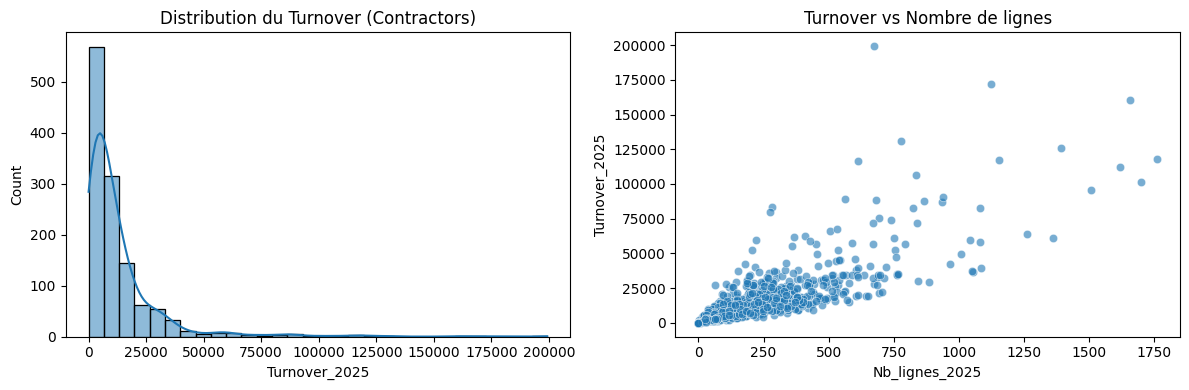

In [44]:
# 1. Distribution du Turnover (en Boxplot et Histogramme)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=contractor, x='Turnover_2025', bins=30, kde=True)
plt.title('Distribution du Turnover (Contractors)')

# 2. Corrélation entre le Nombre de lignes et le Turnover
plt.subplot(1, 2, 2)
sns.scatterplot(data=contractor, x='Nb_lignes_2025', y='Turnover_2025', alpha=0.6)
plt.title('Turnover vs Nombre de lignes')
plt.tight_layout()
plt.show()

### Panier moyen

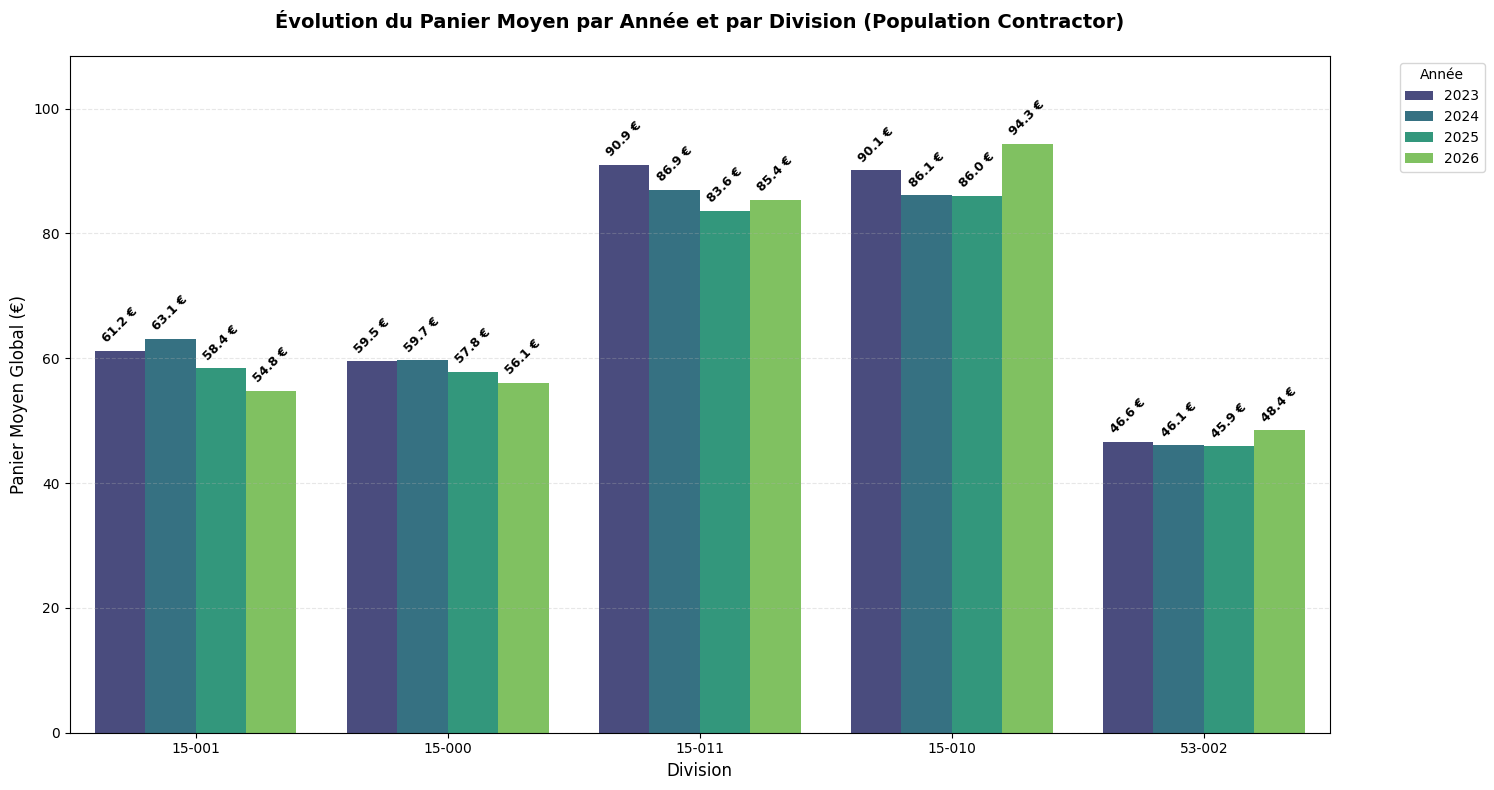

In [45]:
# 1. Sélection et passage au format "long"
cols_analyse = ['division', 'Panier_Moyen_2023', 'Panier_Moyen_2024', 'Panier_Moyen_2025', 'Panier_Moyen_2026']
df_long = contractor[cols_analyse].melt(id_vars=['division'], var_name='Année', value_name='Panier_Moyen')
df_long['Année'] = df_long['Année'].str.replace('Panier_Moyen_', '')
df_long = df_long[df_long['Panier_Moyen'] > 0]

# 2. Configuration de la figure
fig, ax = plt.subplots(figsize=(15, 8))

# 3. Création du barplot (on le stocke dans une variable pour pouvoir lire ses barres)
graph = sns.barplot(
    data=df_long, 
    x='division', 
    y='Panier_Moyen', 
    hue='Année', 
    errorbar=None,      
    palette='viridis',
    ax=ax
)

# 4. Ajout des étiquettes de valeur au-dessus de CHAQUE barre

for container in graph.containers:
    ax.bar_label(
        container, 
        fmt='%.1f €',       
        padding=4,        
        fontsize=9,       
        fontweight='bold',
        rotation=45        
    )

# 5. Habillage et finitions
plt.title('Évolution du Panier Moyen par Année et par Division (Population Contractor)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Division', fontsize=12)
plt.ylabel('Panier Moyen Global (€)', fontsize=12)
plt.legend(title='Année', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# On donne un peu d'espace vertical en haut pour éviter que les étiquettes dépassent du cadre
ax.set_ylim(0, df_long.groupby(['Année', 'division'])['Panier_Moyen'].mean().max() * 1.15)

# 6. Affichage
plt.tight_layout()
plt.show()

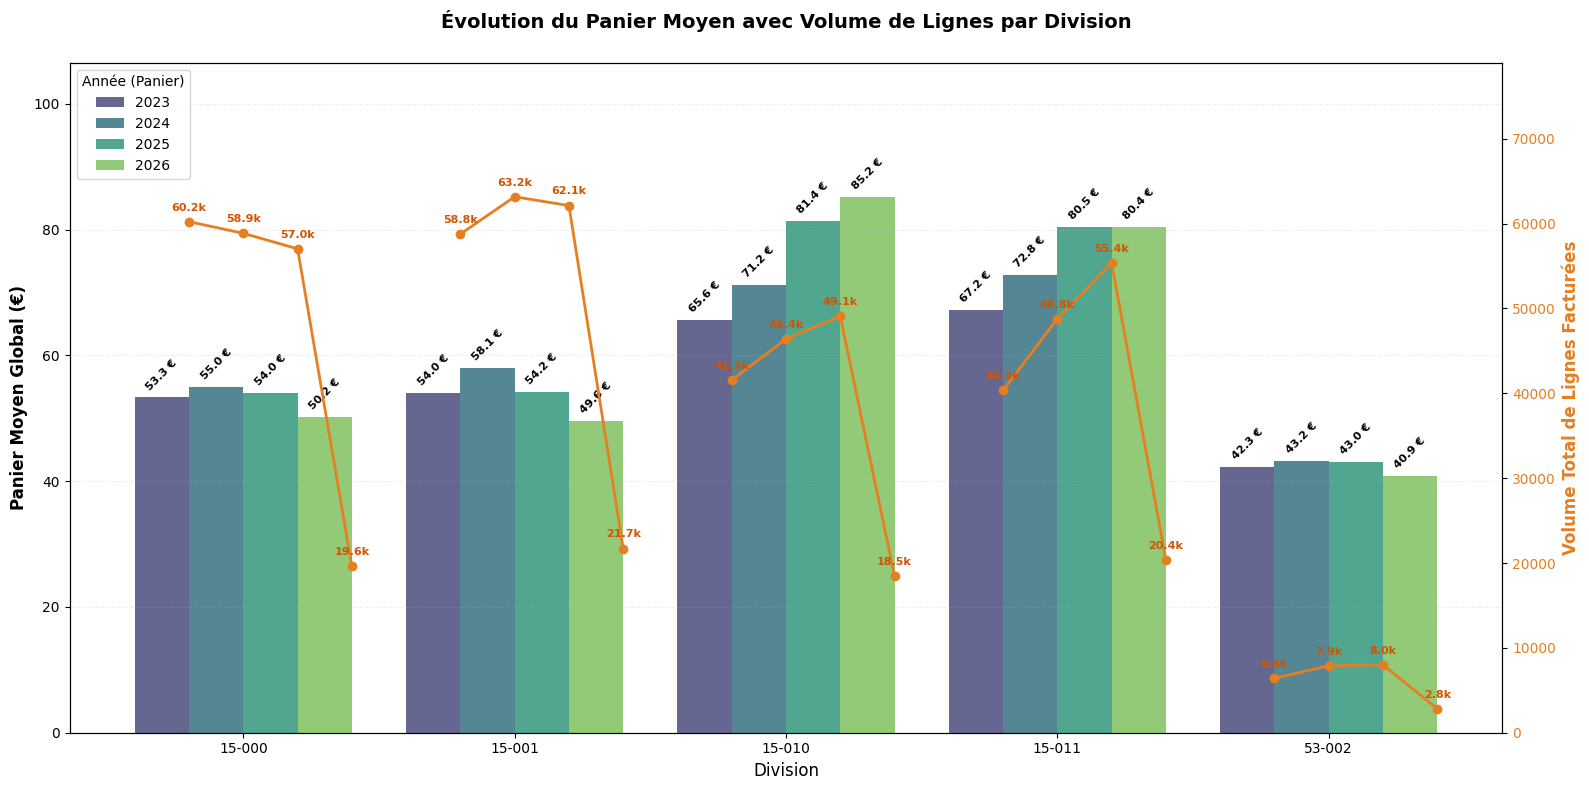

In [46]:
# 1. Sélection et passage au format "long"
cols_paniers = ['division', 'Panier_Moyen_2023', 'Panier_Moyen_2024', 'Panier_Moyen_2025', 'Panier_Moyen_2026']
cols_lignes = ['division', 'Nb_lignes_2023', 'Nb_lignes_2024', 'Nb_lignes_2025', 'Nb_lignes_2026']

divisions_visibles = ['15-001', '15-000', '15-010', '15-011', '53-002']
df_filtered = contractor[contractor['division'].isin(divisions_visibles)].copy()
df_filtered['division'] = df_filtered['division'].astype(str)

# Résumé par division
df_div = df_filtered.groupby('division', as_index=False).agg({
    **{col: 'mean' for col in cols_paniers if col != 'division'},
    **{col: 'sum' for col in cols_lignes if col != 'division'}
})

# Formatage Long
df_p = df_div[['division'] + [c for c in cols_paniers if c != 'division']].melt(id_vars='division', var_name='Année', value_name='Panier_Moyen')
df_p['Année'] = df_p['Année'].str.replace('Panier_Moyen_', '')

df_l = df_div[['division'] + [c for c in cols_lignes if c != 'division']].melt(id_vars='division', var_name='Année', value_name='Nombre_Lignes')
df_l['Année'] = df_l['Année'].str.replace('Nb_lignes_', '')

df_plot = pd.merge(df_p, df_l, on=['division', 'Année']).sort_values(['division', 'Année']).reset_index(drop=True)

# 2. Configuration de la figure et création du double axe
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# --- AXE 1 : Les Barres du Panier Moyen ---
graph_bars = sns.barplot(
    data=df_plot, 
    x='division', 
    y='Panier_Moyen', 
    hue='Année', 
    palette='viridis',
    ax=ax1,
    alpha=0.85
)

# Étiquettes au-dessus de chaque barre
for container in graph_bars.containers:
    ax1.bar_label(container, fmt='%.1f €', padding=4, fontsize=8, fontweight='bold', rotation=45)

# --- AXE 2 : Les segments de courbes par Division ---
annees_uniques = sorted(df_plot['Année'].unique())
divisions_uniques = sorted(df_plot['division'].unique())
width = 0.8 / len(annees_uniques)

# Listes qui accueilleront nos coordonnées et nos données
positions_x = []
valeurs_y = []

for i, div in enumerate(divisions_uniques):
    df_sub = df_plot[df_plot['division'] == div]
    
    for j, annee in enumerate(annees_uniques):
        pos = i + (j - 1.5) * width + (width / 2) # Centre exact de la barre
        val = df_sub.loc[df_sub['Année'] == annee, 'Nombre_Lignes'].values[0]
        
        positions_x.append(pos)
        valeurs_y.append(val)
        
    # ASTUCE : À la fin de chaque division, on injecte None pour briser la ligne
    positions_x.append(np.nan)
    valeurs_y.append(np.nan)

# Tracé de la courbe segmentée
color_line = '#e67e22'
ax2.plot(
    positions_x, 
    valeurs_y, 
    color=color_line, 
    marker='o', 
    linewidth=2, 
    markersize=6, 
    label='Nombre de lignes',
    linestyle='-'
)

# Ajout des étiquettes uniquement sur les vraies valeurs (on ignore les NaN)
for x_pos, val in zip(positions_x, valeurs_y):
    if not np.isnan(val):
        label_txt = f'{val/1000:.1f}k' if val >= 1000 else f'{int(val)}'
        ax2.annotate(
            label_txt,
            (x_pos, val),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center',
            fontweight='bold',
            color='#d35400',
            fontsize=8
        )

# 3. Habillage, axes et légendes
plt.title('Évolution du Panier Moyen avec Volume de Lignes par Division', fontsize=14, fontweight='bold', pad=25)

ax1.set_xlabel('Division', fontsize=12)
ax1.set_ylabel('Panier Moyen Global (€)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volume Total de Lignes Facturées', color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)

ax1.legend(title='Année (Panier)', loc='upper left')

# Ajustement des échelles (1.25 pour laisser de l'espace aux textes)
ax1.set_ylim(0, df_plot['Panier_Moyen'].max() * 1.25)
ax2.set_ylim(0, df_plot['Nombre_Lignes'].max() * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

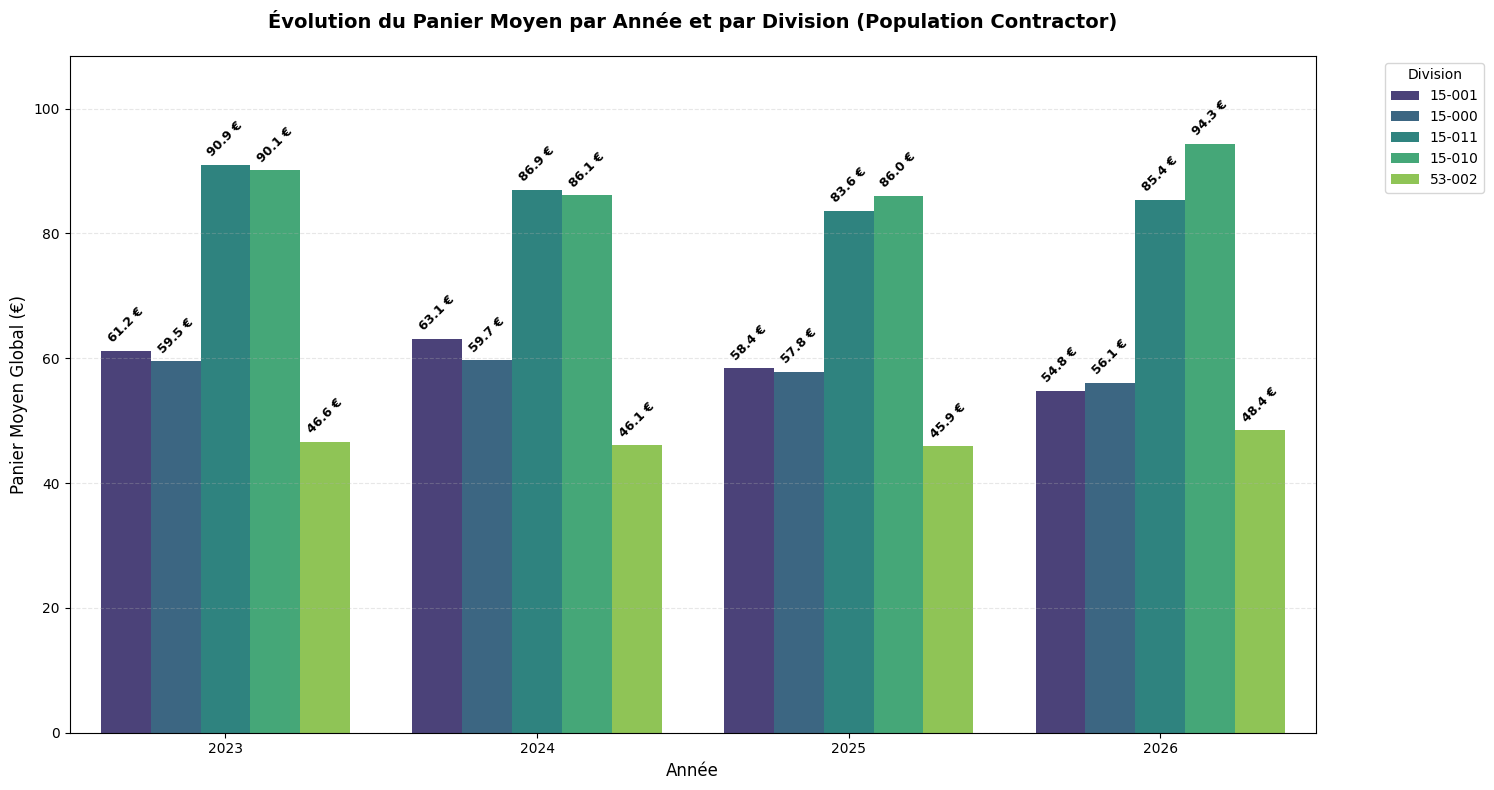

In [47]:
# 1. Sélection et passage au format "long"
cols_analyse = ['division', 'Panier_Moyen_2023', 'Panier_Moyen_2024', 'Panier_Moyen_2025', 'Panier_Moyen_2026']
df_long = contractor[cols_analyse].melt(id_vars=['division'], var_name='Année', value_name='Panier_Moyen')
df_long['Année'] = df_long['Année'].str.replace('Panier_Moyen_', '')
df_long = df_long[df_long['Panier_Moyen'] > 0]

# 2. Configuration de la figure
fig, ax = plt.subplots(figsize=(15, 8))

# 3. Création du barplot (on le stocke dans une variable pour pouvoir lire ses barres)
graph = sns.barplot(
    data=df_long, 
    x='Année', 
    y='Panier_Moyen', 
    hue='division', 
    errorbar=None,      
    palette='viridis',
    ax=ax
)

# 4. Ajout des étiquettes de valeur au-dessus de CHAQUE barre

for container in graph.containers:
    ax.bar_label(
        container, 
        fmt='%.1f €',       
        padding=4,        
        fontsize=9,       
        fontweight='bold',
        rotation=45        
    )

# 5. Habillage et finitions
plt.title('Évolution du Panier Moyen par Année et par Division (Population Contractor)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Panier Moyen Global (€)', fontsize=12)
plt.legend(title='Division', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# On donne un peu d'espace vertical en haut pour éviter que les étiquettes dépassent du cadre
ax.set_ylim(0, df_long.groupby(['Année', 'division'])['Panier_Moyen'].mean().max() * 1.15)

# 6. Affichage
plt.tight_layout()
plt.show()

# Comparaison clients contractor/no contractor

In [48]:
# On enlève les divisions qui ne sont pas dans contractor car pas cohérent pour l'analyse
non_contractor=non_contractor.loc[non_contractor['division'].isin(contractor['division'])]

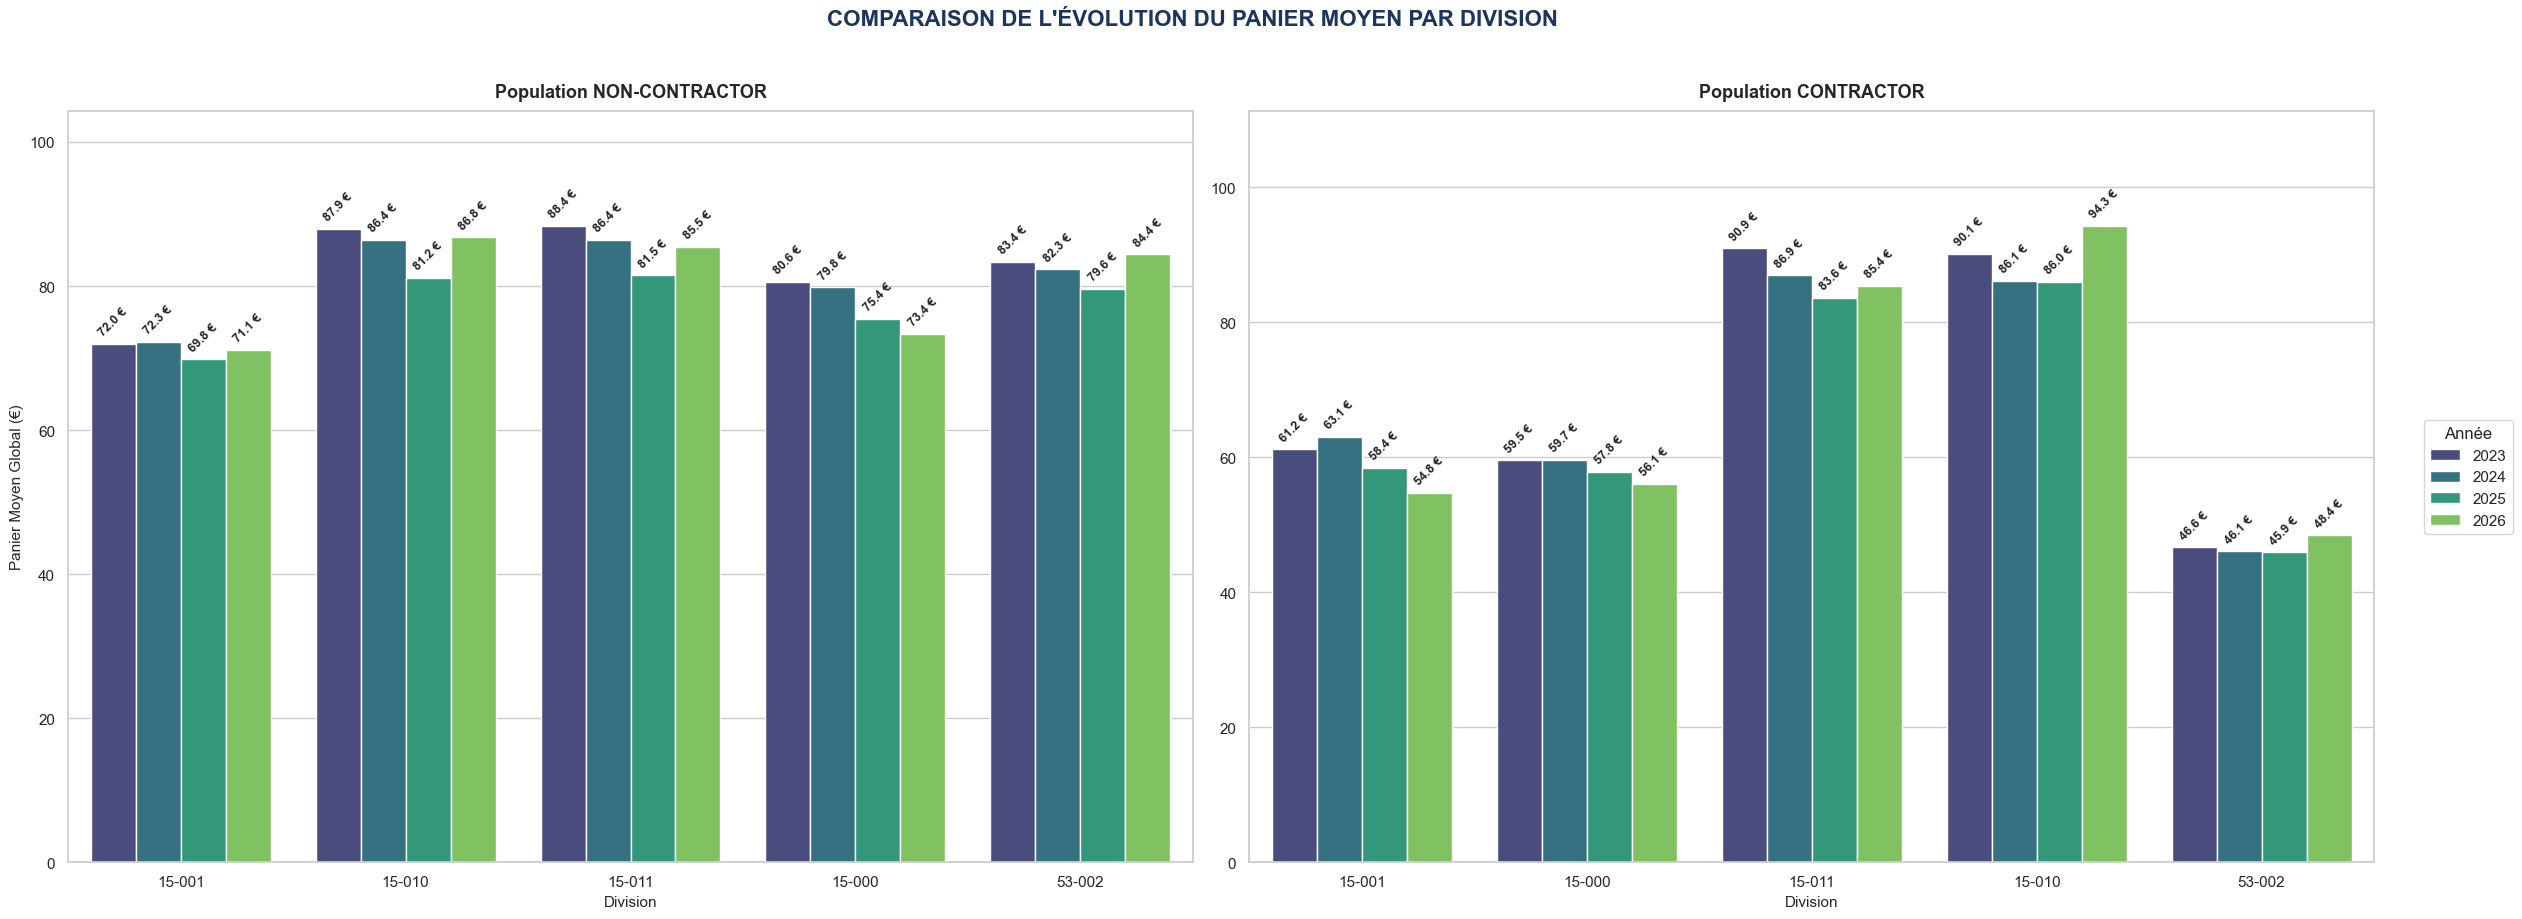

In [49]:
# On s'assure que le thème est propre
sns.set_theme(style="whitegrid")

cols_analyse = [
    "division",
    "Panier_Moyen_2023",
    "Panier_Moyen_2024",
    "Panier_Moyen_2025",
    "Panier_Moyen_2026",
]

# ==========================================
# 1. PRÉPARATION DES DONNÉES (NON-CONTRACTOR)
# ==========================================
df_long_non = non_contractor[cols_analyse].melt(
    id_vars=["division"], var_name="Année", value_name="Panier_Moyen"
)
df_long_non["Année"] = df_long_non["Année"].str.replace("Panier_Moyen_", "")
df_long_non = df_long_non[df_long_non["Panier_Moyen"] > 0]

# ==========================================
# 2. PRÉPARATION DES DONNÉES (CONTRACTOR)
# ==========================================
df_long_cont = contractor[cols_analyse].melt(
    id_vars=["division"], var_name="Année", value_name="Panier_Moyen"
)
df_long_cont["Année"] = df_long_cont["Année"].str.replace("Panier_Moyen_", "")
df_long_cont = df_long_cont[df_long_cont["Panier_Moyen"] > 0]


# ==========================================
# 3. CONFIGURATION DE LA FIGURE (1 LIGNE, 2 COLONNES)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(24, 9))


# ------------------------------------------
# GRAPH_1 : POPULATION NON-CONTRACTOR (À GAUCHE)
# ------------------------------------------
graph_non = sns.barplot(
    data=df_long_non,
    x="division",
    y="Panier_Moyen",
    hue="Année",
    errorbar=None,
    palette="viridis",
    ax=axes[0],
)

for container in graph_non.containers:
    axes[0].bar_label(
        container,
        fmt="%.1f €",
        padding=4,
        fontsize=9,
        fontweight="bold",
        rotation=45,
    )

axes[0].set_title(
    "Population NON-CONTRACTOR", fontsize=13, fontweight="bold", pad=10
)
axes[0].set_xlabel("Division", fontsize=11)
axes[0].set_ylabel("Panier Moyen Global (€)", fontsize=11)
axes[0].get_legend().remove()  # On enlève la légende individuelle

# Calcul dynamique de la limite Y pour que les étiquettes ne dépassent pas
max_y_non = (
    df_long_non.groupby(["Année", "division"])["Panier_Moyen"].mean().max()
)
axes[0].set_ylim(0, max_y_non * 1.18)


# ------------------------------------------
# GRAPH_2 : POPULATION CONTRACTOR (À DROITE)
# ------------------------------------------
graph_cont = sns.barplot(
    data=df_long_cont,
    x="division",
    y="Panier_Moyen",
    hue="Année",
    errorbar=None,
    palette="viridis",
    ax=axes[1],
)

for container in graph_cont.containers:
    axes[1].bar_label(
        container,
        fmt="%.1f €",
        padding=4,
        fontsize=9,
        fontweight="bold",
        rotation=45,
    )

axes[1].set_title(
    "Population CONTRACTOR", fontsize=13, fontweight="bold", pad=10
)
axes[1].set_xlabel("Division", fontsize=11)
axes[1].set_ylabel("", fontsize=11)
axes[1].get_legend().remove()

# Calcul dynamique de la limite Y
max_y_cont = (
    df_long_cont.groupby(["Année", "division"])["Panier_Moyen"].mean().max()
)
axes[1].set_ylim(0, max_y_cont * 1.18)


# ==========================================
# 4. TITRE GLOBAL ET LÉGENDE UNIQUE
# ==========================================
# Ajout d'un grand titre général (y=1.02 pour laisser respirer avec tight_layout)
plt.suptitle(
    "COMPARAISON DE L'ÉVOLUTION DU PANIER MOYEN PAR DIVISION",
    fontsize=16,
    fontweight="bold",
    color="#1a365d",
    y=1.02,
)

# On extrait les étiquettes de la légende depuis le premier graphique pour créer une légende unique
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Année",
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize=11,
)

plt.tight_layout()
plt.show()

### CA et nombre d'achats

In [50]:
# Statistiques clés sur le Chiffre d'Affaires et le volume de lignes
print(contractor[['Turnover_2025', 'Nb_lignes_2025']].describe().round(2))

       Turnover_2025  Nb_lignes_2025
count        1232.00          1232.0
mean        12609.91          188.04
std         17925.22          216.39
min             0.00             0.0
25%          3248.54            54.0
50%          7271.26           116.0
75%         14774.78           253.0
max        199274.70          1761.0


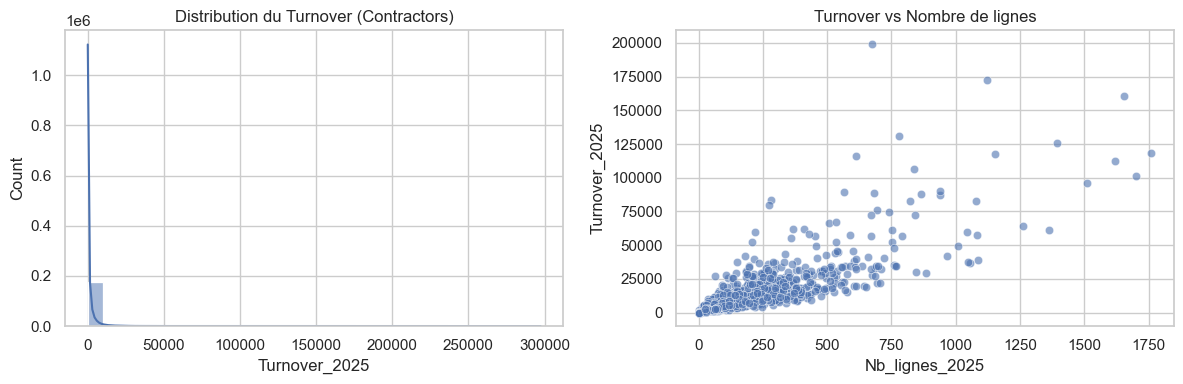

In [51]:
# 1. Distribution du Turnover (en Boxplot et Histogramme)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=non_contractor, x='Turnover_2025', bins=30, kde=True)
plt.title('Distribution du Turnover (Contractors)')

# 2. Corrélation entre le Nombre de lignes et le Turnover
plt.subplot(1, 2, 2)
sns.scatterplot(data=contractor, x='Nb_lignes_2025', y='Turnover_2025', alpha=0.6)
plt.title('Turnover vs Nombre de lignes')
plt.tight_layout()
plt.show()

# Avant/après

In [52]:
contractor.columns

Index(['compagny', 'division', 'code_client', 'act_val_cust_3M',
       'customer_value_score', 'branche', 'clp_contrat_ap_stat', 'country',
       'group_key', 'customer_service',
       ...
       'Panier_Moyen_2024', 'Panier_Moyen_2025', 'Panier_Moyen_2026',
       'is_BERA_M', 'annees_depuis_1ere_facture',
       'annees_depuis_dernier_achat', 'annees_entre_1ere_et_derniere_facture',
       'code_departemental', 'Annee_Signature', 'Annee_Signature_N_1'],
      dtype='object', length=224)

In [53]:
print(f"Base d'analyse prête : {contractor.shape[0]} clients appariés.")

# 2. Re-pivoter les données de CA (Wide to Long) pour analyser Avant vs Après
# On isole les colonnes de Chiffre d'Affaires
cols_ca = [f'Turnover_{annee}' for annee in range(2016, 2027)]

df_long_ca = pd.melt(
    contractor,
    id_vars=['compagny', 'code_client', 'Annee_Signature'],
    value_vars=cols_ca,
    var_name='Annee_CA_Brute',
    value_name='Turnover'
)

df_long_ca

Base d'analyse prête : 1232 clients appariés.


,compagny,code_client,Annee_Signature,Annee_CA_Brute,Turnover
0,FR15,1500154200,2020,Turnover_2016,3958.370117
1,FR15,1500213400,2025,Turnover_2016,7398.350098
2,FR15,1500326200,2023,Turnover_2016,3414.659912
3,FR15,1500331500,2025,Turnover_2016,189.900009
4,FR15,1500437100,2024,Turnover_2016,698.289978
...,...,...,...,...,...
13547,FR53,5303147400,2023,Turnover_2026,0.000000
13548,FR53,5303158500,2023,Turnover_2026,1250.180054
13549,FR53,5303240000,2023,Turnover_2026,4223.500000
13550,FR53,5303251500,2024,Turnover_2026,17232.400391


In [54]:
df_long_ca['Annee_CA_Brute'] = df_long_ca['Annee_CA_Brute'].str[9:]
# On extrait l'année numérique du CA
df_long_ca['Annee_CA'] = df_long_ca['Annee_CA_Brute'].str.extract('(\\d+)').astype(int)

In [55]:
# On harmonise les formats de données
df_long_ca['Annee_CA']=df_long_ca['Annee_CA'].astype('int32')


--- ÉVOLUTION DU CA MOYEN AUTOUR DE LA SIGNATURE ---
                     mean       median         sum  count
Delta_Annee                                              
-3            6963.640137  2105.610107   8001216.5   1149
-2            8502.150391  3847.060059  10474651.0   1232
-1           10803.629883  5844.129883  13310074.0   1232
0            13743.790039  8800.679688  16932354.0   1232
1            11662.049805  6781.580078  12828252.0   1100
2            10380.290039  5672.939941   8055104.0    776
3            10482.349609  5852.939941   5062973.0    483


C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\1702199351.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


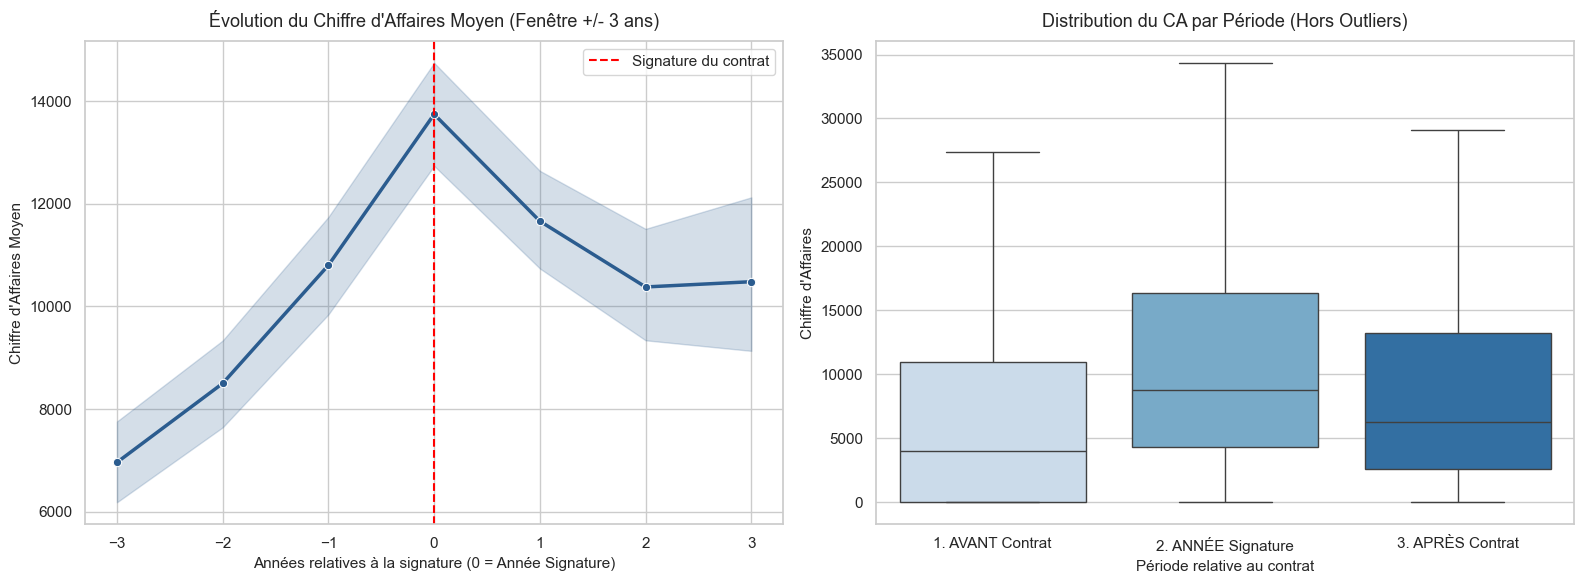


 Pourcentage de clients augmentant leur CA l'année suivant la signature : 57.00%


In [56]:
# 3. Calcul de la distance temporelle (Delta Années)
# 0 = Année de la signature, -1 = Année précédente, 1 = Année suivante
df_long_ca['Delta_Annee'] = df_long_ca['Annee_CA'] - df_long_ca['Annee_Signature']

# On filtre pour garder une fenêtre pertinente autour du contrat (ex: 3 ans avant, 3 ans après)
df_fenetre = df_long_ca[(df_long_ca['Delta_Annee'] >= -3) & (df_long_ca['Delta_Annee'] <= 3)].copy()

# On labellise la période pour faciliter la lecture des graphiques
df_fenetre['Periode'] = np.select(
    [df_fenetre['Delta_Annee'] < 0, df_fenetre['Delta_Annee'] == 0, df_fenetre['Delta_Annee'] > 0],
    ['1. AVANT Contrat', '2. ANNÉE Signature', '3. APRÈS Contrat'],default='Inconnu'
)

# 4. AGRÉGATION ET STATISTIQUES DESCRIPTIVES
print("\n--- ÉVOLUTION DU CA MOYEN AUTOUR DE LA SIGNATURE ---")
stats_evol = df_fenetre.groupby('Delta_Annee')['Turnover'].agg(['mean', 'median', 'sum', 'count']).round(2)
print(stats_evol)

# 5. VISUALISATIONS GRAPHIQUES
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique A : Évolution du CA Moyen par rapport à l'année de signature
sns.lineplot(
    data=df_fenetre, 
    x='Delta_Annee', 
    y='Turnover', 
    marker='o', 
    linewidth=2.5, 
    color='#2b5c8f',
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Signature du contrat')
axes[0].set_title("Évolution du Chiffre d'Affaires Moyen (Fenêtre +/- 3 ans)", fontsize=13, pad=10)
axes[0].set_xlabel("Années relatives à la signature (0 = Année Signature)", fontsize=11)
axes[0].set_ylabel("Chiffre d'Affaires Moyen", fontsize=11)
axes[0].legend()

# Graphique B : Distribution (Boxplot) du CA Avant vs Après (en masquant les extrêmes pour la lisibilité)
sns.boxplot(
    data=df_fenetre, 
    x='Periode', 
    y='Turnover', 
    palette='Blues', 
    showfliers=False, # Masque les gros outliers pour mieux voir la tendance des boîtes
    ax=axes[1]
)
axes[1].set_title("Distribution du CA par Période (Hors Outliers)", fontsize=13, pad=10)
axes[1].set_xlabel("Période relative au contrat", fontsize=11)
axes[1].set_ylabel("Chiffre d'Affaires", fontsize=11)

plt.tight_layout()
plt.show()

# 6. ANALYSE DES COMPORTEMENTS : Taux de clients qui progressent
# On compare le CA à l'année -1 vs l'année +1
ca_avant = df_fenetre[df_fenetre['Delta_Annee'] == -1].set_index(['compagny', 'code_client'])['Turnover']
ca_apres = df_fenetre[df_fenetre['Delta_Annee'] == 1].set_index(['compagny', 'code_client'])['Turnover']

df_croissance = pd.DataFrame({'CA_Avant': ca_avant, 'CA_Apres': ca_apres}).dropna()
df_croissance['Evolution_Brute'] = df_croissance['CA_Apres'] - df_croissance['CA_Avant']
df_croissance['Est_En_Croissance'] = df_croissance['Evolution_Brute'] > 0

tx_croissance = df_croissance['Est_En_Croissance'].mean() * 100
print(f"\n Pourcentage de clients augmentant leur CA l'année suivant la signature : {tx_croissance:.2f}%")

# Profil client à N-1

In [57]:
contractor_GC=contractor.loc[contractor['GrandCompte']==True]

## Création table avec données relatives sur l'année de signature

In [58]:
contractor

,compagny,division,code_client,act_val_cust_3M,customer_value_score,branche,clp_contrat_ap_stat,country,group_key,customer_service,...,Panier_Moyen_2024,Panier_Moyen_2025,Panier_Moyen_2026,is_BERA_M,annees_depuis_1ere_facture,annees_depuis_dernier_achat,annees_entre_1ere_et_derniere_facture,code_departemental,Annee_Signature,Annee_Signature_N_1
401,FR15,15-001,1500154200,0,69.0,4903,BK,FR,1521383900,BERA-M,...,36.09,46.98,53.40,True,21,0,21,22,2020,2019
531,FR15,15-001,1500213400,1,96.0,4078,BK,FR,1550076500,BERA-M,...,74.37,77.22,85.32,True,21,0,21,82,2025,2024
813,FR15,15-000,1500326200,1,88.0,5237,BK,FR,1577026400,BERA-M,...,52.15,54.28,40.88,True,21,0,21,22,2023,2022
825,FR15,15-011,1500331500,1,80.0,3001,AE,FR,1543275200,BERA-M,...,41.25,36.98,90.31,True,21,0,21,24,2025,2024
1191,FR15,15-011,1500437100,0,47.0,3003,None,FR,1539381700,BERA-M,...,56.41,33.49,28.03,True,21,0,21,83,2024,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401094,FR53,53-002,5303147400,0,50.0,7008,BK,FR,5300654400,BERA-M,...,36.64,32.30,0.00,True,4,1,3,80,2023,2022
401191,FR53,53-002,5303158500,0,57.0,7003,BK,FR,5300110100,BERA-M,...,72.81,41.96,43.11,True,3,0,3,45,2023,2022
401907,FR53,53-002,5303240000,1,86.0,7007,None,FR,5301868800,BERA-M,...,53.22,65.10,74.10,True,3,0,3,51,2023,2022
402006,FR53,53-002,5303251500,1,99.0,7004,None,FR,None,BERA-M,...,39.22,44.98,42.97,True,3,0,3,82,2024,2023


In [59]:
# 1. Liste des préfixes de métriques globales à extraire et renommer
metriques_globales = ["Turnover_", "Nb_lignes_", "Panier_Moyen_"]

# 2. Extraction des codes familles directement depuis les colonnes du DataFrame
codes_familles = list(
    set(
        [
            col.split("_")[1]
            for col in contractor.columns
            if isinstance(col, str) and col.startswith("Famille_")
        ]
    )
)

print(f"Familles trouvées dans les colonnes : {codes_familles}")

# Initialisation de la liste pour stocker les lignes de notre nouvelle table
donnees_relatives = []

# ==========================================================
# BOUCLE PRINCIPALE : TRAITEMENT CLIENT PAR CLIENT
# ==========================================================
for idx, ligne_client in contractor.iterrows():
    cust_code = ligne_client["code_client"]
    comp_code = ligne_client["compagny"]
    annee_sig = int(ligne_client["Annee_Signature"])

    # Dictionnaire temporaire pour stocker les données relatives de ce client
    row_client = {
        "compagny": comp_code,
        "code_client": cust_code,
        "Annee_Signature": annee_sig,
    }

    # Si la colonne 'division' est présente, on la conserve directement
    if "division" in contractor.columns:
        row_client["division"] = ligne_client["division"]

    # On remonte le temps de N-1 à N-4 par rapport à l'année de signature
    # t = 1 correspond à N-1, t = 2 à N-2, etc.
    for t in range(1, 5):
        annee_calendaire = annee_sig - t

        # --- A. Extraction des métriques globales (Turnover, Nb_lignes, Panier_Moyen) ---
        for metrique in metriques_globales:
            col_origine = f"{metrique}{annee_calendaire}"
            col_nouvelle = f"{metrique}N_signature_{t}"

            if col_origine in contractor.columns:
                row_client[col_nouvelle] = ligne_client[col_origine]
            else:
                row_client[col_nouvelle] = 0

        # --- B. Extraction du Mix de chaque Famille ---
        for fam in codes_familles:
            col_fam_origine = f"Famille_{fam}_{annee_calendaire}"
            col_fam_nouvelle = f"Famille_{fam}_N_signature_{t}"

            if col_fam_origine in contractor.columns:
                row_client[col_fam_nouvelle] = ligne_client[col_fam_origine]
            else:
                row_client[col_fam_nouvelle] = 0

    donnees_relatives.append(row_client)

# ==========================================================
# CRÉATION DU DATAFRAME FINAL
# ==========================================================
df_contractor_relatif = pd.DataFrame(donnees_relatives)

# Ordonner proprement les colonnes pour la lisibilité
cols_fixes = ["compagny", "code_client", "Annee_Signature"]
if "division" in df_contractor_relatif.columns:
    cols_fixes.append("division")

cols_metriques_ordonnees = sorted(
    [col for col in df_contractor_relatif.columns if col not in cols_fixes]
)

df_contractor_relatif = df_contractor_relatif[
    cols_fixes + cols_metriques_ordonnees
]

# Vérification du résultat
print(f"Dimensions de la nouvelle table : {df_contractor_relatif.shape}")
df_contractor_relatif.head()

Familles trouvées dans les colonnes : ['2', '6', '12', '4', '8', '14', '3', '10', '5', '9', '11', '16', '13', '1', '0']
Dimensions de la nouvelle table : (1232, 76)


,compagny,code_client,Annee_Signature,division,Famille_0_N_signature_1,Famille_0_N_signature_2,Famille_0_N_signature_3,Famille_0_N_signature_4,Famille_10_N_signature_1,Famille_10_N_signature_2,...,Nb_lignes_N_signature_3,Nb_lignes_N_signature_4,Panier_Moyen_N_signature_1,Panier_Moyen_N_signature_2,Panier_Moyen_N_signature_3,Panier_Moyen_N_signature_4,Turnover_N_signature_1,Turnover_N_signature_2,Turnover_N_signature_3,Turnover_N_signature_4
0,FR15,1500154200,2020,15-001,39.0,84.0,16.0,14.0,22.0,31.0,...,133.0,180.0,0.00,0.00,0.0,0,7433.810059,7023.759766,3406.010010,3958.370117
1,FR15,1500213400,2025,15-001,1.0,1.0,2.0,2.0,3.0,7.0,...,86.0,407.0,74.37,62.73,0.0,0,9816.309570,7214.049805,6519.359863,21478.429688
2,FR15,1500326200,2023,15-000,138.0,59.0,39.0,47.0,51.0,19.0,...,249.0,205.0,0.00,0.00,0.0,0,13783.570312,12811.910156,13298.250000,5500.729980
3,FR15,1500331500,2025,15-011,7.0,9.0,9.0,15.0,14.0,12.0,...,52.0,46.0,41.25,81.47,0.0,0,2928.939941,5540.299805,2190.709961,1327.309937
4,FR15,1500437100,2024,15-011,7.0,8.0,0.0,0.0,6.0,9.0,...,20.0,32.0,43.35,0.00,0.0,0,3381.449951,2259.689941,801.880005,1128.189941


In [60]:
#Ajout des colonnes de caractéristiques coface et clients
clients_data=contractor[['compagny','division','code_client','act_val_cust_3M','customer_value_score','branche','clp_contrat_ap_stat','country','group_key','customer_service','start_validity','end_validity','SOCIETE','COFACE_FJ_INSEE','COFACE_LIB_FJ_INSEE','COFACE_DATE_CREA_ENT','COFACE_NAF08','COFACE_LIBELLE_NAF08','pot_40_calc','branche_activite','branche_division','branche_libelle','effectif','GrandCompte','NOTE_COFACE']]

In [61]:
df_contractor_relatif=pd.merge(df_contractor_relatif,clients_data, on=['compagny','division','code_client'], how='left')

In [62]:
# Split GC
df_contractor_relatif_GC=df_contractor_relatif.loc[df_contractor_relatif['GrandCompte']==True]

## Répartition achats par famille

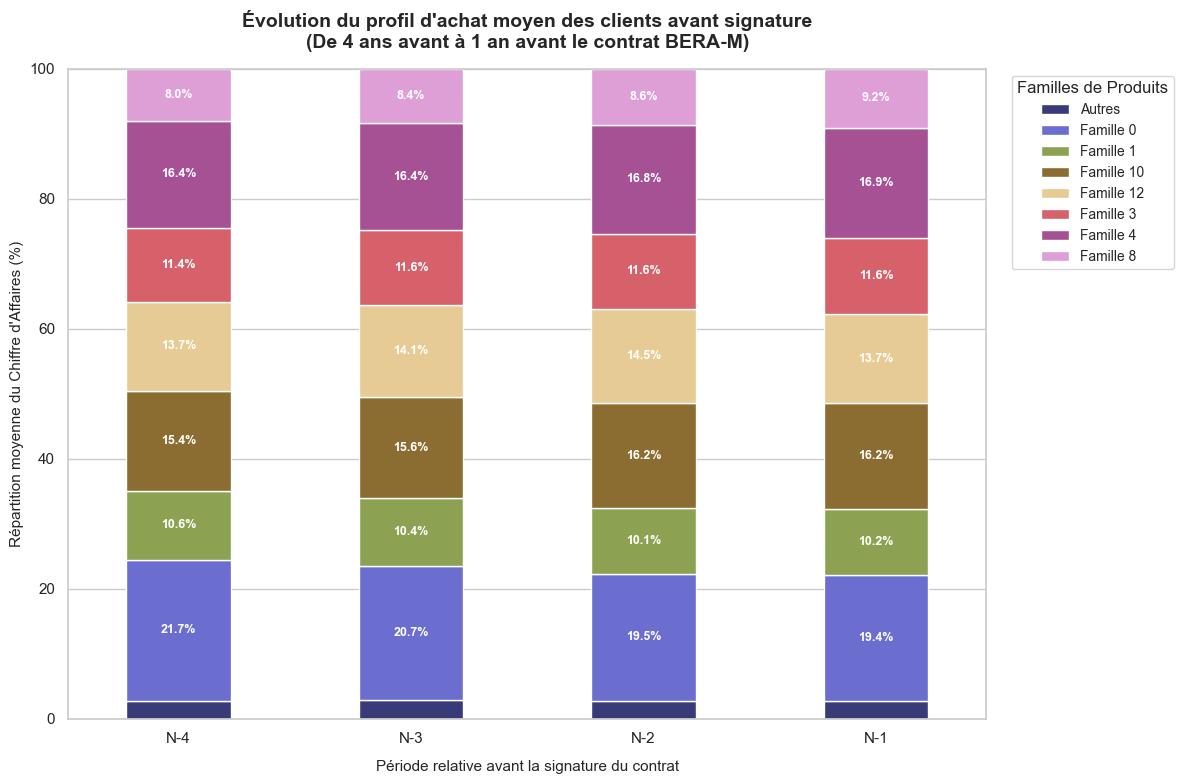


--- TABLEAU DES PARTS RELATIVES MOYENNES (DE N-4 À N-1) ---
Famille_Group  Autres  Famille 0  Famille 1  Famille 10  Famille 12  \
Delta_Temps                                                           
N-4              2.81      21.69      10.55       15.40       13.72   
N-3              2.86      20.69      10.35       15.57       14.11   
N-2              2.77      19.54      10.08       16.17       14.48   
N-1              2.72      19.37      10.25       16.20       13.73   

Famille_Group  Famille 3  Famille 4  Famille 8  
Delta_Temps                                     
N-4                11.35      16.43       8.04  
N-3                11.57      16.44       8.41  
N-2                11.60      16.77       8.59  
N-1                11.62      16.94       9.18  


In [63]:
# On s'assure que le thème est propre pour tes livrables
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LISTER LES COLONNES DE FAMILLES RELATIVES
# ==========================================
# On isole toutes les colonnes qui suivent le pattern Famille_XX_N_signature_X
cols_familles = [
    col
    for col in df_contractor_relatif.columns
    if col.startswith("Famille_")
]

# ==========================================
# 2. PASSAGE AU FORMAT LONG (WIDE TO LONG)
# ==========================================
df_long = pd.melt(
    df_contractor_relatif,
    id_vars=["compagny", "code_client", "Annee_Signature"],
    value_vars=cols_familles,
    var_name="Famille_Relative_Brute",
    value_name="Part_CA_Client",
)

# Extraction propre du code de la famille et de l'indice temporel (1 à 4)
# .squeeze() transforme le DataFrame extrait en Series pour que le .map() fonctionne
df_long["Famille"] = df_long["Famille_Relative_Brute"].str.extract(
    r"Famille_([A-Za-z0-9]+)_"
).squeeze()

df_long["Delta_Temps"] = (
    df_long["Famille_Relative_Brute"]
    .str.extract(r"_(\d+)$")
    .squeeze()
    .map({"1": "N-1", "2": "N-2", "3": "N-3", "4": "N-4"})
)
# ==========================================
# 3. REGROUPEMENT DES TOP FAMILLES
# ==========================================
# On identifie les 7 familles les plus importantes globalement sur l'historique avant signature
top_familles = (
    df_long.groupby("Famille")["Part_CA_Client"]
    .sum()
    .nlargest(7)
    .index.tolist()
)

# Application du groupe (les autres deviennent 'Autres')
df_long["Famille_Group"] = df_long["Famille"].apply(
    lambda x: f"Famille {x}" if x in top_familles else "Autres"
)

# ==========================================
# 4. CALCUL DES MOYENNES PAR PÉRIODE RELATIVE
# ==========================================
# Moyenne de la part de CA pour chaque période relative et chaque groupe de famille
profil_relatif = (
    df_long.groupby(["Delta_Temps", "Famille_Group"])["Part_CA_Client"]
    .mean()
    .reset_index()
)

# Pivot pour le format de graphique (Index = Les années relatives)
df_pivot_relatif = profil_relatif.pivot(
    index="Delta_Temps", columns="Famille_Group", values="Part_CA_Client"
).fillna(0)

# On réordonne l'index pour avoir une lecture chronologique logique : de N-4 à N-1
ordre_chronologique = ["N-4", "N-3", "N-2", "N-1"]
df_pivot_relatif = df_pivot_relatif.reindex(ordre_chronologique)

# ==========================================
# CORRECTION SOUHAITÉE : NORMALISATION À 100%
# ==========================================
# Pour que toutes les barres aillent strictement à 100% sur l'axe Y
df_pivot_relatif_100 = (
    df_pivot_relatif.div(df_pivot_relatif.sum(axis=1), axis=0) * 100
)

# ==========================================
# 5. VISUALISATION (BARRES EMPILÉES 100%)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

df_pivot_relatif_100.plot(
    kind="bar", stacked=True, cmap="tab20b", ax=ax, width=0.45
)

# Ajustements esthétiques et labels
ax.set_title(
    "Évolution du profil d'achat moyen des clients avant signature\n(De 4 ans avant à 1 an avant le contrat BERA-M)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Période relative avant la signature du contrat", fontsize=11, labelpad=10)
ax.set_ylabel("Répartition moyenne du Chiffre d'Affaires (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.set_xticklabels(df_pivot_relatif_100.index, rotation=0)

# Légende externe
ax.legend(
    title="Familles de Produits",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
)

# Affichage des pourcentages sur les segments significatifs (> 4%)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 4:
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white",
        )

plt.tight_layout()
plt.show()

# ==========================================
# 6. EXPORT DU TABLEAU DE SYNTHÈSE
# ==========================================
print("\n--- TABLEAU DES PARTS RELATIVES MOYENNES (DE N-4 À N-1) ---")
print(df_pivot_relatif_100.round(2))

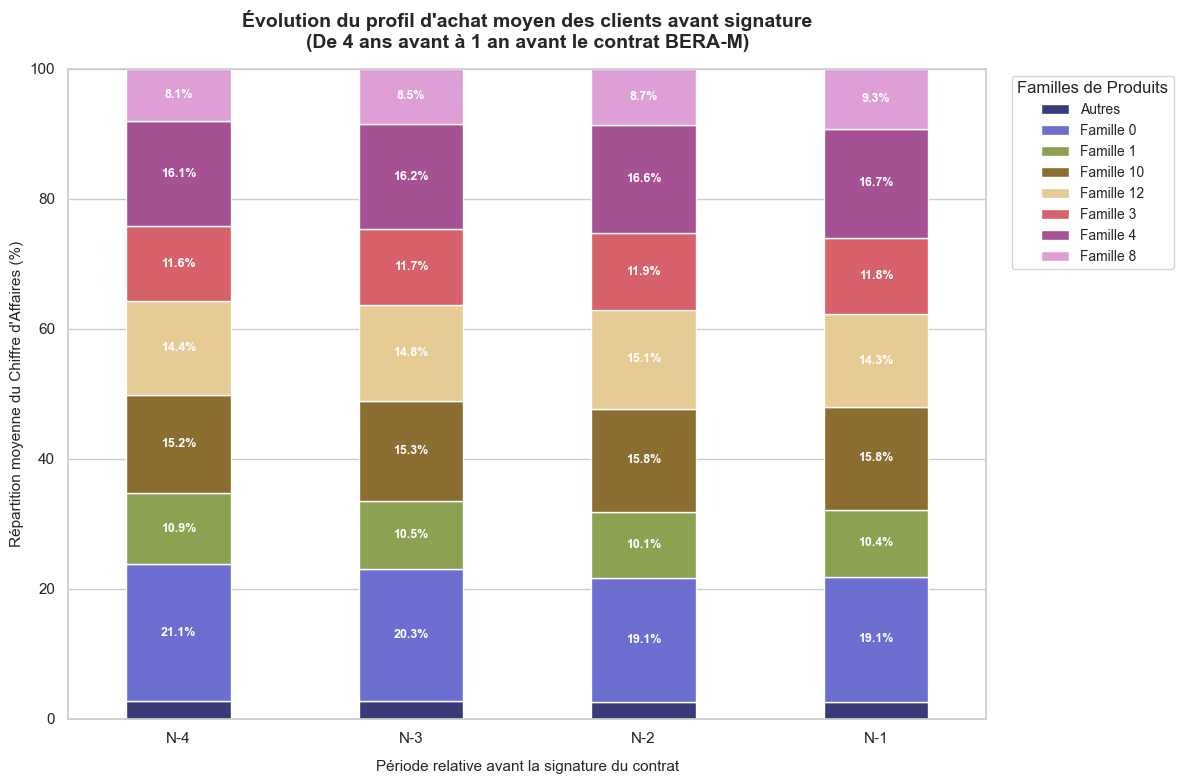


--- TABLEAU DES PARTS RELATIVES MOYENNES (DE N-4 À N-1) ---
Famille_Group  Autres  Famille 0  Famille 1  Famille 10  Famille 12  \
Delta_Temps                                                           
N-4              2.73      21.09      10.86       15.16       14.41   
N-3              2.73      20.32      10.52       15.27       14.81   
N-2              2.67      19.06      10.15       15.84       15.14   
N-1              2.65      19.15      10.38       15.75       14.30   

Famille_Group  Famille 3  Famille 4  Famille 8  
Delta_Temps                                     
N-4                11.55      16.13       8.07  
N-3                11.65      16.19       8.51  
N-2                11.87      16.57       8.69  
N-1                11.78      16.68       9.31  


In [64]:
# On s'assure que le thème est propre pour tes livrables
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LISTER LES COLONNES DE FAMILLES RELATIVES
# ==========================================
# On isole toutes les colonnes qui suivent le pattern Famille_XX_N_signature_X
cols_familles = [
    col
    for col in df_contractor_relatif_GC.columns
    if col.startswith("Famille_")
]

# ==========================================
# 2. PASSAGE AU FORMAT LONG (WIDE TO LONG)
# ==========================================
df_long = pd.melt(
    df_contractor_relatif_GC,
    id_vars=["compagny", "code_client", "Annee_Signature"],
    value_vars=cols_familles,
    var_name="Famille_Relative_Brute",
    value_name="Part_CA_Client",
)

# Extraction propre du code de la famille et de l'indice temporel (1 à 4)
# .squeeze() transforme le DataFrame extrait en Series pour que le .map() fonctionne
df_long["Famille"] = df_long["Famille_Relative_Brute"].str.extract(
    r"Famille_([A-Za-z0-9]+)_"
).squeeze()

df_long["Delta_Temps"] = (
    df_long["Famille_Relative_Brute"]
    .str.extract(r"_(\d+)$")
    .squeeze()
    .map({"1": "N-1", "2": "N-2", "3": "N-3", "4": "N-4"})
)
# ==========================================
# 3. REGROUPEMENT DES TOP FAMILLES
# ==========================================
# On identifie les 7 familles les plus importantes globalement sur l'historique avant signature
top_familles = (
    df_long.groupby("Famille")["Part_CA_Client"]
    .sum()
    .nlargest(7)
    .index.tolist()
)

# Application du groupe (les autres deviennent 'Autres')
df_long["Famille_Group"] = df_long["Famille"].apply(
    lambda x: f"Famille {x}" if x in top_familles else "Autres"
)

# ==========================================
# 4. CALCUL DES MOYENNES PAR PÉRIODE RELATIVE
# ==========================================
# Moyenne de la part de CA pour chaque période relative et chaque groupe de famille
profil_relatif = (
    df_long.groupby(["Delta_Temps", "Famille_Group"])["Part_CA_Client"]
    .mean()
    .reset_index()
)

# Pivot pour le format de graphique (Index = Les années relatives)
df_pivot_relatif = profil_relatif.pivot(
    index="Delta_Temps", columns="Famille_Group", values="Part_CA_Client"
).fillna(0)

# On réordonne l'index pour avoir une lecture chronologique logique : de N-4 à N-1
ordre_chronologique = ["N-4", "N-3", "N-2", "N-1"]
df_pivot_relatif = df_pivot_relatif.reindex(ordre_chronologique)

# ==========================================
# CORRECTION SOUHAITÉE : NORMALISATION À 100%
# ==========================================
# Pour que toutes les barres aillent strictement à 100% sur l'axe Y
df_pivot_relatif_100 = (
    df_pivot_relatif.div(df_pivot_relatif.sum(axis=1), axis=0) * 100
)

# ==========================================
# 5. VISUALISATION (BARRES EMPILÉES 100%)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 8))

df_pivot_relatif_100.plot(
    kind="bar", stacked=True, cmap="tab20b", ax=ax, width=0.45
)

# Ajustements esthétiques et labels
ax.set_title(
    "Évolution du profil d'achat moyen des clients avant signature\n(De 4 ans avant à 1 an avant le contrat BERA-M)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Période relative avant la signature du contrat", fontsize=11, labelpad=10)
ax.set_ylabel("Répartition moyenne du Chiffre d'Affaires (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.set_xticklabels(df_pivot_relatif_100.index, rotation=0)

# Légende externe
ax.legend(
    title="Familles de Produits",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
)

# Affichage des pourcentages sur les segments significatifs (> 4%)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 4:
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white",
        )

plt.tight_layout()
plt.show()

# ==========================================
# 6. EXPORT DU TABLEAU DE SYNTHÈSE
# ==========================================
print("\n--- TABLEAU DES PARTS RELATIVES MOYENNES (DE N-4 À N-1) ---")
print(df_pivot_relatif_100.round(2))

## Evolution CA moyen avant signature

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\2744165025.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


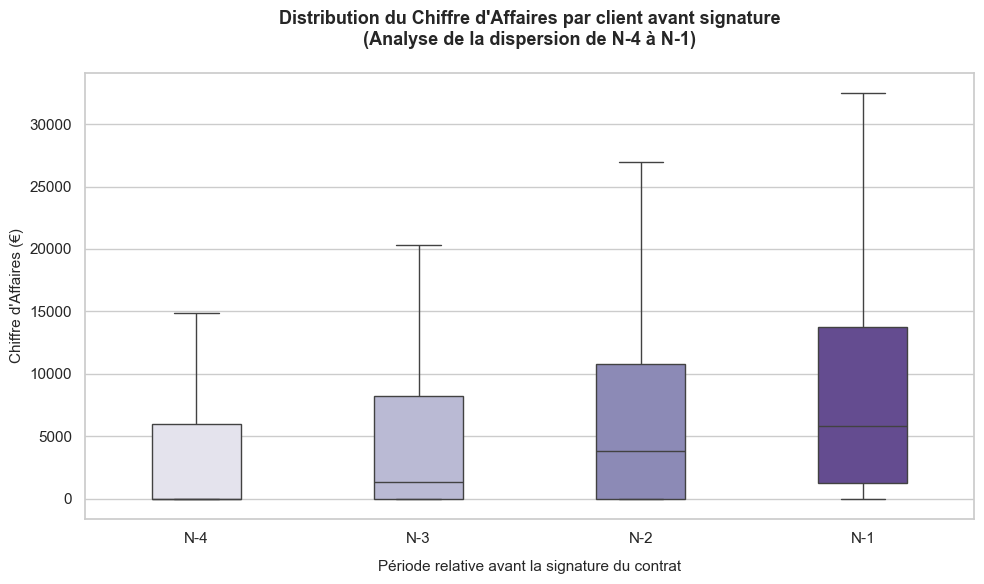

In [65]:
# Configuration du thème
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LISTER ET PASSER AU FORMAT LONG
# ==========================================
cols_turnover = [
    col for col in df_contractor_relatif.columns if col.startswith("Turnover_")
]

df_long_ca = pd.melt(
    df_contractor_relatif,
    id_vars=["compagny", "code_client", "Annee_Signature"],
    value_vars=cols_turnover,
    var_name="Turnover_Relative_Brute",
    value_name="Turnover",
)

df_long_ca["Delta_Temps"] = (
    df_long_ca["Turnover_Relative_Brute"]
    .str.extract(r"_(\d+)$")
    .squeeze()
    .map({"1": "N-1", "2": "N-2", "3": "N-3", "4": "N-4"})
)

ordre_chronologique = ["N-4", "N-3", "N-2", "N-1"]

# ==========================================
# 2. TRACÉ DU BOXPLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_long_ca,
    x="Delta_Temps",
    y="Turnover",
    order=ordre_chronologique,
    palette="Purples",
    showfliers=False,
    ax=ax,
    width=0.4,
)

# ==========================================
# 3. HABILLAGE ET FINITIONS
# ==========================================
ax.set_title(
    "Distribution du Chiffre d'Affaires par client avant signature\n(Analyse de la dispersion de N-4 à N-1)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Période relative avant la signature du contrat", fontsize=11, labelpad=10)
ax.set_ylabel("Chiffre d'Affaires (€)", fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\2119845991.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


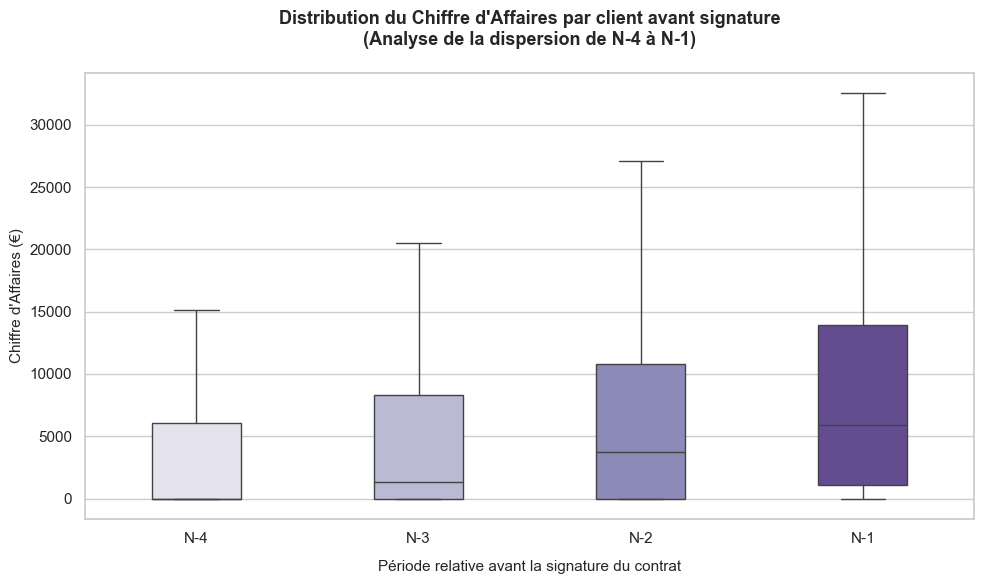

In [66]:
# Configuration du thème
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LISTER ET PASSER AU FORMAT LONG
# ==========================================
cols_turnover = [
    col for col in df_contractor_relatif_GC.columns if col.startswith("Turnover_")
]

df_long_ca = pd.melt(
    df_contractor_relatif_GC,
    id_vars=["compagny", "code_client", "Annee_Signature"],
    value_vars=cols_turnover,
    var_name="Turnover_Relative_Brute",
    value_name="Turnover",
)

df_long_ca["Delta_Temps"] = (
    df_long_ca["Turnover_Relative_Brute"]
    .str.extract(r"_(\d+)$")
    .squeeze()
    .map({"1": "N-1", "2": "N-2", "3": "N-3", "4": "N-4"})
)

ordre_chronologique = ["N-4", "N-3", "N-2", "N-1"]

# ==========================================
# 2. TRACÉ DU BOXPLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_long_ca,
    x="Delta_Temps",
    y="Turnover",
    order=ordre_chronologique,
    palette="Purples",
    showfliers=False,
    ax=ax,
    width=0.4,
)

# ==========================================
# 3. HABILLAGE ET FINITIONS
# ==========================================
ax.set_title(
    "Distribution du Chiffre d'Affaires par client avant signature\n(Analyse de la dispersion de N-4 à N-1)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Période relative avant la signature du contrat", fontsize=11, labelpad=10)
ax.set_ylabel("Chiffre d'Affaires (€)", fontsize=11)

plt.tight_layout()
plt.show()

## Panier moyen

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\1749319541.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


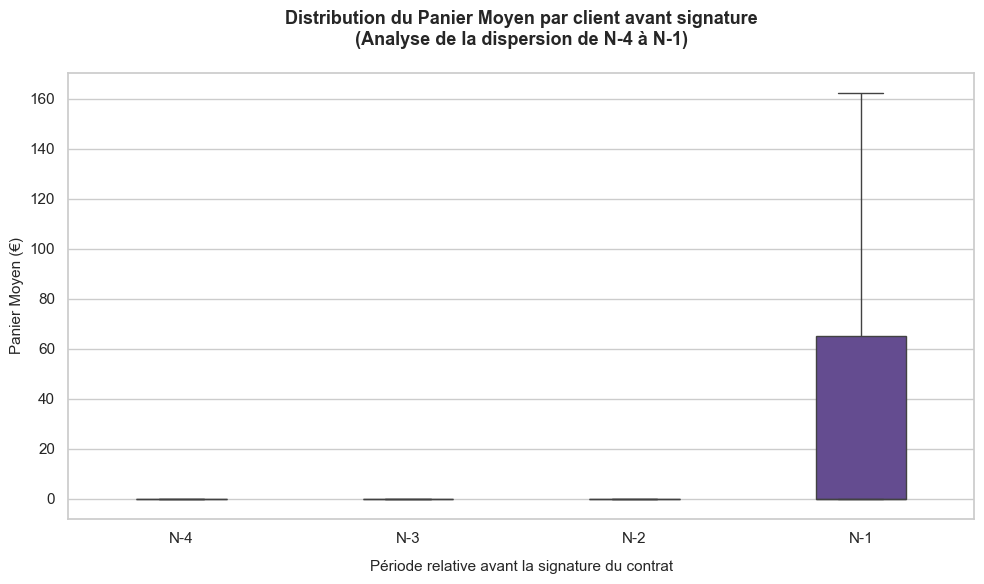

In [67]:
# Configuration du thème
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LISTER ET PASSER AU FORMAT LONG
# ==========================================
cols_turnover = [
    col for col in df_contractor_relatif.columns if col.startswith("Panier_Moyen_")
]

df_long_ca = pd.melt(
    df_contractor_relatif,
    id_vars=["compagny", "code_client", "Annee_Signature"],
    value_vars=cols_turnover,
    var_name="Panier_Moyen_Relative_Brute",
    value_name="Panier_Moyen",
)

df_long_ca["Delta_Temps"] = (
    df_long_ca["Panier_Moyen_Relative_Brute"]
    .str.extract(r"_(\d+)$")
    .squeeze()
    .map({"1": "N-1", "2": "N-2", "3": "N-3", "4": "N-4"})
)

ordre_chronologique = ["N-4", "N-3", "N-2", "N-1"]

# ==========================================
# 2. TRACÉ DU BOXPLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_long_ca,
    x="Delta_Temps",
    y="Panier_Moyen",
    order=ordre_chronologique,
    palette="Purples",
    showfliers=False,
    ax=ax,
    width=0.4,
)

# ==========================================
# 3. HABILLAGE ET FINITIONS
# ==========================================
ax.set_title(
    "Distribution du Panier Moyen par client avant signature\n(Analyse de la dispersion de N-4 à N-1)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Période relative avant la signature du contrat", fontsize=11, labelpad=10)
ax.set_ylabel("Panier Moyen (€)", fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_2088\2231541013.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


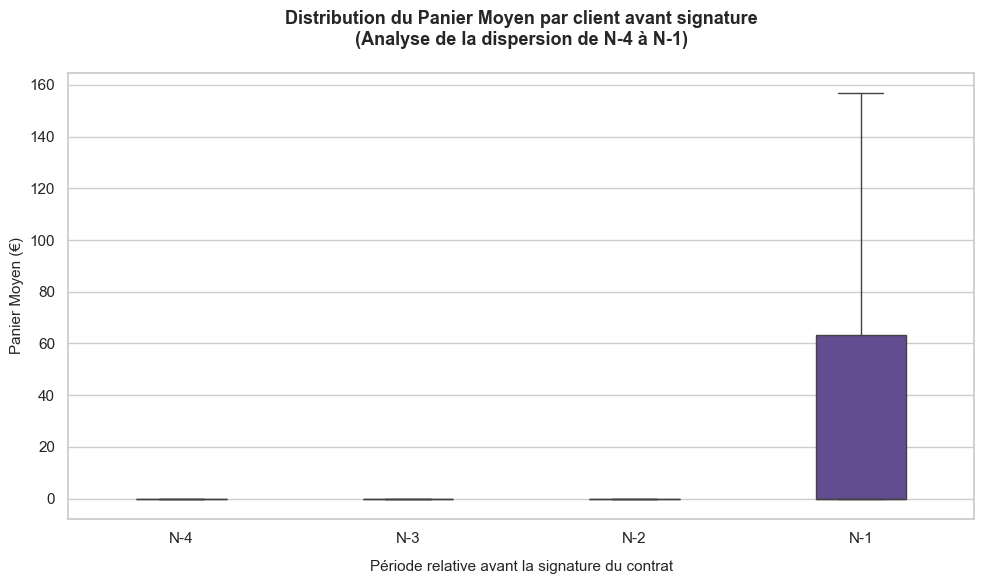

In [68]:
# Configuration du thème
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LISTER ET PASSER AU FORMAT LONG
# ==========================================
cols_turnover = [
    col for col in df_contractor_relatif_GC.columns if col.startswith("Panier_Moyen_")
]

df_long_ca = pd.melt(
    df_contractor_relatif_GC,
    id_vars=["compagny", "code_client", "Annee_Signature"],
    value_vars=cols_turnover,
    var_name="Panier_Moyen_Relative_Brute",
    value_name="Panier_Moyen",
)

df_long_ca["Delta_Temps"] = (
    df_long_ca["Panier_Moyen_Relative_Brute"]
    .str.extract(r"_(\d+)$")
    .squeeze()
    .map({"1": "N-1", "2": "N-2", "3": "N-3", "4": "N-4"})
)

ordre_chronologique = ["N-4", "N-3", "N-2", "N-1"]

# ==========================================
# 2. TRACÉ DU BOXPLOT
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_long_ca,
    x="Delta_Temps",
    y="Panier_Moyen",
    order=ordre_chronologique,
    palette="Purples",
    showfliers=False,
    ax=ax,
    width=0.4,
)

# ==========================================
# 3. HABILLAGE ET FINITIONS
# ==========================================
ax.set_title(
    "Distribution du Panier Moyen par client avant signature\n(Analyse de la dispersion de N-4 à N-1)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Période relative avant la signature du contrat", fontsize=11, labelpad=10)
ax.set_ylabel("Panier Moyen (€)", fontsize=11)

plt.tight_layout()
plt.show()

## Données contractor par rapoort à Année signature

In [69]:
# Définition des préfixes recherchés
prefixes = ("Turnover_", "Famille_", "Nb_lignes_", "Panier_Moyen_")

# Création de la liste par filtrage des colonnes
columns_data_contractor_relatif = [
    col for col in df_contractor_relatif.columns if col.startswith(prefixes)
]

# Vérification rapide du nombre de colonnes récupérées
print(
    f"Nombre de colonnes sélectionnées : {len(columns_data_contractor_relatif)}"
)

Nombre de colonnes sélectionnées : 72


In [70]:
df_contractor_relatif[columns_data_contractor_relatif].describe()

,Famille_0_N_signature_1,Famille_0_N_signature_2,Famille_0_N_signature_3,Famille_0_N_signature_4,Famille_10_N_signature_1,Famille_10_N_signature_2,Famille_10_N_signature_3,Famille_10_N_signature_4,Famille_11_N_signature_1,Famille_11_N_signature_2,...,Nb_lignes_N_signature_3,Nb_lignes_N_signature_4,Panier_Moyen_N_signature_1,Panier_Moyen_N_signature_2,Panier_Moyen_N_signature_3,Panier_Moyen_N_signature_4,Turnover_N_signature_1,Turnover_N_signature_2,Turnover_N_signature_3,Turnover_N_signature_4
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,...,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.0,1232.000000,1232.000000,1232.000000,1232.000000
mean,26.347403,21.423701,17.835227,15.592532,22.038961,17.730519,13.425325,11.066558,4.430195,3.671266,...,104.420455,86.873377,39.449245,18.586291,4.411615,0.0,10803.631113,8502.152192,6494.494042,5346.387862
std,53.842636,45.257283,42.098079,43.205303,38.831952,38.940398,33.312409,28.121105,8.121338,7.492420,...,183.536887,175.570483,56.859756,40.898985,20.441047,0.0,17473.504784,15484.092966,12761.405240,13254.949490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1245.927490,0.000000,0.000000,0.000000
50%,7.000000,3.000000,0.000000,0.000000,10.000000,6.000000,1.000000,0.000000,2.000000,0.500000,...,23.000000,0.000000,0.000000,0.000000,0.000000,0.0,5844.129883,3847.065063,1313.650024,0.000000
75%,28.000000,24.000000,16.000000,10.000000,27.000000,21.250000,16.000000,11.000000,5.000000,4.000000,...,143.250000,107.000000,65.282500,0.000000,0.000000,0.0,13762.809814,10788.800049,8201.242798,5959.045166
max,602.000000,576.000000,509.000000,493.000000,606.000000,868.000000,746.000000,423.000000,71.000000,73.000000,...,2811.000000,2459.000000,700.060000,336.520000,252.550000,0.0,222341.515625,223622.843750,166829.500000,202105.937500


# Table d'entrainement

In [71]:
clients

,compagny,division,code_client,act_val_cust_3M,customer_value_score,branche,clp_contrat_ap_stat,country,group_key,customer_service,...,Panier_Moyen_2024,Panier_Moyen_2025,Panier_Moyen_2026,is_BERA_M,annees_depuis_1ere_facture,annees_depuis_dernier_achat,annees_entre_1ere_et_derniere_facture,code_departemental,Annee_Signature,Annee_Signature_N_1
1,FR15,15-001,1500000300,0,NaN,4890,None,FR,1578242400,None,...,0.00,0.00,0.00,False,21,3,18,16,<NA>,<NA>
3,FR15,15-001,1500000900,1,87.0,4903,None,FR,None,None,...,0.00,40.70,32.20,False,21,0,21,88,<NA>,<NA>
5,FR15,15-010,1500002000,0,68.0,1210,None,FR,1521785500,None,...,133.95,120.33,106.19,False,21,0,21,13,<NA>,<NA>
6,FR15,15-000,1500002100,0,NaN,5999,None,FR,None,None,...,0.00,0.00,0.00,False,21,5,16,20,<NA>,<NA>
7,FR15,15-001,1500002400,1,56.0,4211,None,FR,None,None,...,67.84,52.50,78.72,False,21,0,21,40,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411093,FR53,53-999,53E907848,0,NaN,9208,None,FR,None,None,...,0.00,18.95,37.84,False,5,0,5,00,<NA>,<NA>
411095,FR53,53-999,53E907899,0,NaN,9208,None,FR,None,None,...,0.00,0.00,71.45,False,6,0,6,00,<NA>,<NA>
411097,FR53,53-999,53E907968,0,NaN,9208,None,FR,None,None,...,0.00,0.00,22.72,False,9,0,9,00,<NA>,<NA>
411098,FR53,53-999,53E908033,0,NaN,9208,None,FR,None,None,...,0.00,0.00,86.84,False,5,0,5,00,<NA>,<NA>


On crée une table avec seulement les variables quantitives qui serviront pour le modèle. On enlève les identifiants pour l'entrainement

In [72]:
# ==========================================================
# 1. PRÉPARATION DE LA POPULATION NON-BERA-M (Vectorisée & Optimisée)
# ==========================================================
df_non_bera = clients[clients['is_BERA_M'] == False].copy()
annee_pivot = 2025

# Extraction automatique des codes familles
codes_familles = list(set([col.split('_')[1] for col in df_non_bera.columns if col.startswith('Famille_')]))

# Initialisation de la table avec les identifiants de base
df_non_bera_relatif = pd.DataFrame({
    'compagny': df_non_bera['compagny'],
    'code_client': df_non_bera['code_client'],
    'division': df_non_bera['division'] if 'division' in df_non_bera.columns else 'Inconnu',
    'is_BERA_M': 0
})

# Remplissage vectorisé (4 itérations au lieu d'une boucle par client)
for t in range(1, 5):
    annee_calendaire = annee_pivot - (t - 1)
    
    # Métriques globales
    for metrique in ["Turnover_", "Nb_lignes_", "Panier_Moyen_"]:
        col_origine = f"{metrique}{annee_calendaire}"
        df_non_bera_relatif[f"{metrique}N_signature_{t}"] = df_non_bera[col_origine] if col_origine in df_non_bera.columns else 0
            
    # Mix Familles
    for fam in codes_familles:
        col_fam_origine = f"Famille_{fam}_{annee_calendaire}"
        df_non_bera_relatif[f"Famille_{fam}_N_signature_{t}"] = df_non_bera[col_fam_origine] if col_fam_origine in df_non_bera.columns else 0

print(f"✅ Table non-BERA générée de manière vectorisée. Dimensions : {df_non_bera_relatif.shape}")

# ==========================================================
# 2. PRÉPARATION DE LA POPULATION BERA-M (Historique Relatif)
# ==========================================================
# On repart de la table df_contractor_relatif que l'on a créée juste avant
df_bera_relatif = df_contractor_relatif.copy()
df_bera_relatif['is_BERA_M'] = 1 # Target à 1

# ==========================================================
# 3. FUSION DES DEUX POPULATIONS 
# ==========================================================

# On calcule les colonnes communes pour les features
colonnes_communes = list(set(df_bera_relatif.columns).intersection(set(df_non_bera_relatif.columns)))

# On s'assure que 'code_client' fait explicitement partie des colonnes extraites
if 'code_client' not in colonnes_communes:
    columns_bera = colonnes_communes + ['code_client']
    columns_non_bera = colonnes_communes + ['code_client']
else:
    columns_bera = colonnes_communes
    columns_non_bera = colonnes_communes

df_final_model = pd.concat([
    df_bera_relatif[columns_bera],
    df_non_bera_relatif[columns_non_bera]
], ignore_index=True)

print(f"✅ Table df_final_model prête avec la clé ! Dimensions : {df_final_model.shape}")

✅ Table non-BERA générée de manière vectorisée. Dimensions : (180830, 76)
✅ Table df_final_model prête avec la clé ! Dimensions : (182062, 76)


## Implémentation autres features

In [73]:
cols_Turnover_ = [col for col in clients.columns if col.startswith("Turnover_")]
cols_Panier_Moyen = [col for col in clients.columns if col.startswith("Panier_Moyen")]
cols_Famille=[col for col in clients.columns if col.startswith("Famille")]
cols_Nb_Ligne= [col for col in clients.columns if col.startswith("Nb_lignes")]

cols_quantitative= cols_Turnover_+cols_Panier_Moyen+cols_Famille+cols_Nb_Ligne
cols_a_implementer = clients[['code_client', 'act_val_cust_3M', 'customer_value_score', 'branche', 'clp_contrat_ap_stat', 'annees_depuis_1ere_facture', 'annees_depuis_dernier_achat', 'code_departemental', 'pot_40_calc', 'GrandCompte', 'NOTE_COFACE', '%EC']]
cols_a_implementer
cols_a_implementer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182062 entries, 1 to 411100
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   code_client                  182062 non-null  object  
 1   act_val_cust_3M              182062 non-null  object  
 2   customer_value_score         90111 non-null   float64 
 3   branche                      182061 non-null  category
 4   clp_contrat_ap_stat          36043 non-null   object  
 5   annees_depuis_1ere_facture   182062 non-null  Int64   
 6   annees_depuis_dernier_achat  182062 non-null  Int64   
 7   code_departemental           182062 non-null  category
 8   pot_40_calc                  157346 non-null  float64 
 9   GrandCompte                  182062 non-null  bool    
 10  NOTE_COFACE                  178259 non-null  object  
 11  %EC                          182062 non-null  float64 
dtypes: Int64(2), bool(1), category(2), float64(3), ob

In [74]:
print("🧹 Début du nettoyage et retypage ciblé de 'cols_a_implementer'...")

# 1. Copie de sécurité
df_prep = cols_a_implementer.copy()

# ==========================================================
# ÉTAPE 1 : RETYPAGE ET NETTOYAGE DES COLONNES SPÉCIFIQUES
# ==========================================================

# NOTE_COFACE en float
if "NOTE_COFACE" in df_prep.columns:
    df_prep["NOTE_COFACE"] = pd.to_numeric(df_prep["NOTE_COFACE"], errors="coerce")
    print("🔹 'NOTE_COFACE' convertie en Float.")

# act_val_cust_3M en booléen
if "act_val_cust_3M" in df_prep.columns:
    
    df_prep["act_val_cust_3M"] = (
        df_prep["act_val_cust_3M"].astype(str).str.replace("#", "0").str.replace("X", "1")
    )
    # On convertit en numérique, puis en type booléen standard
    df_prep["act_val_cust_3M"] = pd.to_numeric(df_prep["act_val_cust_3M"], errors="coerce").fillna(0).astype(bool)
    print("🔹 'act_val_cust_3M' convertie en Booléen (True/False).")

🧹 Début du nettoyage et retypage ciblé de 'cols_a_implementer'...
🔹 'NOTE_COFACE' convertie en Float.
🔹 'act_val_cust_3M' convertie en Booléen (True/False).


In [75]:
# ==========================================================
# ÉTAPE 2 : RETYPAGE DES TYPES INT64 (VERS FLOAT32 POUR LA RAM)
# ==========================================================
# Les types 'Int64' de Pandas font planter Scikit-Learn. On les passe en float32 (qui gère aussi les NaN)
cols_int64 = ["annees_depuis_1ere_facture", "annees_depuis_dernier_achat"]

for col in cols_int64:
    if col in df_prep.columns:
        df_prep[col] = df_prep[col].astype("float32")
print("🔹 Colonnes 'Int64' converties en Float32 (compatible avec les modèles).")


print("⚙️ Encodage optimisé (Zéro colonne à rallonge)...")

# 1. Traitement spécifique du code départemental (Conversion en numérique unique)
if "code_departemental" in df_prep.columns:
    # errors='coerce' transforme les codes contenant des lettres (ex: 2A, 2B) en NaN, gérés par XGBoost
    df_prep["code_departemental"] = pd.to_numeric(df_prep["code_departemental"], errors="coerce").astype("float32")
    print("🔹 'code_departemental' compressé dans une seule colonne numérique.")

# 2. Préparation des variables catégorielles pour XGBoost (Native Categorical)

colonnes_textes = ["clp_contrat_ap_stat", "branche"]

for col in colonnes_textes:
    if col in df_prep.columns:
        df_prep[col] = df_prep[col].astype("category")
print("🔹 'clp_contrat_ap_stat' et 'branche' configurées en types catégoriels natifs.")

# 3. Finalisation du DataFrame
df_cleaned_final = df_prep

print(f"\n✅ Nettoyage terminé ! {df_cleaned_final.shape}")
df_cleaned_final.info()

🔹 Colonnes 'Int64' converties en Float32 (compatible avec les modèles).
⚙️ Encodage optimisé (Zéro colonne à rallonge)...
🔹 'code_departemental' compressé dans une seule colonne numérique.
🔹 'clp_contrat_ap_stat' et 'branche' configurées en types catégoriels natifs.

✅ Nettoyage terminé ! (182062, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 182062 entries, 1 to 411100
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   code_client                  182062 non-null  object  
 1   act_val_cust_3M              182062 non-null  bool    
 2   customer_value_score         90111 non-null   float64 
 3   branche                      182061 non-null  category
 4   clp_contrat_ap_stat          36043 non-null   category
 5   annees_depuis_1ere_facture   182062 non-null  float32 
 6   annees_depuis_dernier_achat  182062 non-null  float32 
 7   code_departemental           182062 non-null  

In [76]:
# ==========================================================
# JOINTURE FINALE ET SÉCURISÉE
# ==========================================================
print("🔗 Fusion des features nettoyées avec le modèle principal...")

df_final_model_enriched = pd.merge(df_final_model, df_cleaned_final, on="code_client", how="left")

print(f"🚀 Table finale enrichie pour le scoring : {df_final_model_enriched.shape}")

🔗 Fusion des features nettoyées avec le modèle principal...
🚀 Table finale enrichie pour le scoring : (182062, 87)


In [77]:
df_final_model_enriched.head(1)

,Famille_6_N_signature_1,Nb_lignes_N_signature_2,Panier_Moyen_N_signature_4,Turnover_N_signature_3,Famille_10_N_signature_2,Famille_0_N_signature_1,Famille_1_N_signature_4,Famille_10_N_signature_4,division,Turnover_N_signature_2,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,%EC
0,0.0,311.0,0,3406.01001,31.0,39.0,14.0,18.0,15-001,7023.759766,...,69.0,4903,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7


# Export table nettoyée

In [78]:
df_final_model_enriched.to_csv('df_final_model_enriched.csv')